# সহজ ভাষায় Notebook Guide

এই notebook-এ theory এবং code পাশাপাশি শেখানো হয়েছে। Technical term English-এ থাকবে, আর explanation Bangla-তে—যাতে code-এর language-এর সাথে পরিচিত থেকেও concept সহজে বোঝা যায়।

## কীভাবে ব্যবহার করবেন?

1. Cell উপর থেকে নিচে sequence অনুযায়ী run করুন।
2. Run করার আগে expected output কী হতে পারে লিখে ভাবুন।
3. Output-এর metric, shape এবং visualization explanation-এর সাথে compare করুন।
4. Error হলে import, file path, data shape এবং dependency একে একে check করুন।
5. Notebook শেষে নিজের ভাষায় লিখুন: এটি কোন problem solve করেছে, কীভাবে করেছে এবং limitation কী।

> **Important:** Notebook-এর সব cell successful run হলেই result correct প্রমাণ হয় না; data leakage, wrong assumption এবং misleading metric-ও validate করতে হবে।

# Class 7 — Statistics for AI: Hypothesis Testing
### AI Engineering Course | Module 2

> **Achievement:** By the end of this notebook, you will conduct a **full A/B test analysis** — determining with statistical rigor whether a prompt change genuinely improved an LLM's accuracy, or whether the improvement was just random chance.

---

### Why Does an AI Engineer Need This?

Every time you:
- Test a new prompt vs. an old one
- Compare two model versions (GPT-4o vs. Claude Sonnet)
- Evaluate whether fine-tuning actually improved performance
- Run a feature experiment on a production ML system

...you are doing **hypothesis testing**. Without it, you are guessing.
With it, you can make statistically defensible claims: *"This prompt change improved accuracy by 4.2 percentage points, and we are 95% confident this was not random chance (p=0.031)."*

---

### Notebook Structure

| Section | Topic | Key Concept |
|---------|-------|-------------|
| 1 | Setup & Synthetic Data | LLM evaluation dataset |
| 2 | Central Limit Theorem | Why sample means are normally distributed |
| 3 | P-values & Significance | What does "statistically significant" actually mean? |
| 4 | One-Sample T-Test | Does the model meet a target accuracy? |
| 5 | Two-Sample T-Test | Is Prompt B truly better than Prompt A? |
| 6 | ANOVA | Does accuracy differ across 4 different prompt styles? |
| 7 | Correlation vs. Causation | Danger of misreading relationships |
| 8 | Full A/B Test Pipeline | End-to-end analysis with decision report |

---
## Section 1 — Setup & Dataset Generation

### Context: What Are We Testing?

Your team built an LLM-powered **customer intent classifier** for a Bangladeshi e-commerce platform.
It reads customer messages and classifies them into: `complaint`, `inquiry`, `feedback`, or `purchase_intent`.

You ran two experiments:
- **Prompt A (Control):** The original system prompt used in production
- **Prompt B (Treatment):** A revised prompt with more specific role instructions and examples

Each prompt was evaluated on **independent random samples** of customer messages.
You recorded whether each classification was **correct** (1) or **wrong** (0).

**The question:** Is Prompt B's accuracy improvement real, or just noise?

**Analogy:** A pharmaceutical company tests a new drug on two patient groups.
The treatment group improves more — but is that the drug, or just random variation?
Hypothesis testing answers this with a probability.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 1.1 — Import Libraries
# ─────────────────────────────────────────────────────────────
#
# WHY these specific libraries?
#   numpy        — Random data generation, array math
#   pandas       — Structured result tables and DataFrames
#   scipy.stats  — THE library for hypothesis tests (t-test, ANOVA, etc.)
#   matplotlib   — Plot distributions, rejection regions
#   seaborn      — Clean statistical visualizations
#
# ANALOGY: A doctor's toolkit. Stethoscope (numpy), patient records (pandas),
# diagnostic lab (scipy.stats), X-ray viewer (matplotlib).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, f_oneway, pearsonr, spearmanr
import warnings

# ── Global Style ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
})
warnings.filterwarnings('ignore')

# ── Reproducibility Seed ─────────────────────────────────────
# WHY: Fixing the seed means every student gets the same dataset
# and the same test results. Critical for graded exercises.
SEED = 42
np.random.seed(SEED)

print("✅ Libraries loaded. Ready to do statistics.")

✅ Libraries loaded. Ready to do statistics.


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 1.2 — Generate LLM Evaluation Dataset
# ─────────────────────────────────────────────────────────────
#
# WHAT: We simulate the output of evaluating an LLM intent classifier.
# For each customer message, the LLM predicted a category, and a
# human annotator marked it correct (1) or wrong (0).
#
# WHY simulate instead of using real data?
# We control the TRUE accuracy of each prompt. This lets us:
#   1. Know the ground truth (Prompt B IS genuinely better by design)
#   2. See whether the hypothesis test correctly detects the difference
#   3. Experiment with sample sizes to understand statistical power
#
# ANALOGY: This is like a controlled experiment in a lab —
# we know the true answer and test if our measurement tool (the t-test)
# can find it. If it can't, we have a power problem.

# ── Experiment Parameters ────────────────────────────────────
N_A = 120      # Sample size for Prompt A (control)
N_B = 120      # Sample size for Prompt B (treatment)

# True underlying accuracy (what the LLM ACTUALLY achieves on the full population)
TRUE_ACCURACY_A = 0.72   # Prompt A: 72% correct classifications
TRUE_ACCURACY_B = 0.80   # Prompt B: 80% correct classifications (genuinely better)
#
# KEY POINT: In a real experiment, you do NOT know these numbers.
# You only observe the sample results. The hypothesis test tells you
# whether the OBSERVED difference is statistically credible.

# ── Generate Binary Outcomes ─────────────────────────────────
# WHY np.random.binomial?
# Each classification is a Bernoulli trial: correct (1) or wrong (0).
# binomial(n=1, p=accuracy) generates one such trial.
# Calling it N times gives N independent trial outcomes.
# This models: "Each message is independently classified, with probability
# TRUE_ACCURACY_X of being correct."

results_a = np.random.binomial(n=1, p=TRUE_ACCURACY_A, size=N_A)  # 0 or 1 per message
results_b = np.random.binomial(n=1, p=TRUE_ACCURACY_B, size=N_B)

# ── Also generate continuous accuracy scores ─────────────────
# WHY: T-tests work on CONTINUOUS data.
# Binary 0/1 data technically requires a proportion test (chi-squared or Z-test).
# To teach T-tests cleanly, we also simulate continuous "confidence scores"
# the model assigns to each prediction (0.0–1.0, higher = more confident).
# Correct predictions cluster around 0.75–0.95, wrong ones around 0.35–0.65.

scores_a = np.where(
    results_a == 1,
    np.random.normal(0.82, 0.10, N_A).clip(0.5, 1.0),   # Correct: high confidence
    np.random.normal(0.48, 0.12, N_A).clip(0.1, 0.65)   # Wrong: low confidence
)
scores_b = np.where(
    results_b == 1,
    np.random.normal(0.88, 0.08, N_B).clip(0.5, 1.0),   # Prompt B: higher confidence when correct
    np.random.normal(0.45, 0.11, N_B).clip(0.1, 0.65)
)

# ── Assemble DataFrames ──────────────────────────────────────
intent_categories = ['complaint', 'inquiry', 'feedback', 'purchase_intent']

df_a = pd.DataFrame({
    'message_id':    [f'MSG-{i:04d}' for i in range(1, N_A + 1)],
    'prompt':        'Prompt A',
    'correct':       results_a,
    'confidence':    scores_a.round(4),
    'intent':        np.random.choice(intent_categories, size=N_A),
    'message_len':   np.random.normal(45, 15, N_A).astype(int).clip(10, 120),
})

df_b = pd.DataFrame({
    'message_id':    [f'MSG-{i:04d}' for i in range(N_A + 1, N_A + N_B + 1)],
    'prompt':        'Prompt B',
    'correct':       results_b,
    'confidence':    scores_b.round(4),
    'intent':        np.random.choice(intent_categories, size=N_B),
    'message_len':   np.random.normal(45, 15, N_B).astype(int).clip(10, 120),
})

# ── Combined Dataset ─────────────────────────────────────────
df = pd.concat([df_a, df_b], ignore_index=True)

# ── Summary ──────────────────────────────────────────────────
obs_acc_a = results_a.mean()
obs_acc_b = results_b.mean()

print("══ EXPERIMENT SUMMARY ══")
print(f"{'':30s} {'Prompt A':>12} {'Prompt B':>12}")
print(f"{'─'*55}")
print(f"{'Sample size':30s} {N_A:>12,} {N_B:>12,}")
print(f"{'True accuracy (hidden)':30s} {TRUE_ACCURACY_A:>12.1%} {TRUE_ACCURACY_B:>12.1%}")
print(f"{'Observed accuracy':30s} {obs_acc_a:>12.1%} {obs_acc_b:>12.1%}")
print(f"{'Observed difference':30s} {obs_acc_b - obs_acc_a:>+24.1%}")
print(f"{'Mean confidence score':30s} {scores_a.mean():>12.4f} {scores_b.mean():>12.4f}")
print()
print("KEY QUESTION: Is the observed difference real, or could it be random chance?")
print("This notebook answers that question rigorously.")

══ EXPERIMENT SUMMARY ══
                                   Prompt A     Prompt B
───────────────────────────────────────────────────────
Sample size                             120          120
True accuracy (hidden)                72.0%        80.0%
Observed accuracy                     71.7%        81.7%
Observed difference                              +10.0%
Mean confidence score                0.7164       0.7912

KEY QUESTION: Is the observed difference real, or could it be random chance?
This notebook answers that question rigorously.


---
## Section 2 — Central Limit Theorem (CLT)

### Topic
The **Central Limit Theorem** states: *Regardless of the shape of the original population distribution, the distribution of **sample means** approaches a normal distribution as sample size increases.*

### Why It Is Relevant to AI
Every hypothesis test (t-test, ANOVA, Z-test) assumes that sample means are normally distributed. The CLT is **why** that assumption is valid even when your raw data is binary (0/1), skewed (revenue), or uniform — as long as n is large enough (typically n ≥ 30).

Without the CLT, none of the tests in this notebook would be mathematically valid.

### How It Works
1. Draw a random sample of size n from ANY distribution
2. Compute the sample mean
3. Repeat 1000 times → collect 1000 sample means
4. The distribution of those 1000 means is approximately **Normal** with:
   - Mean = population mean (μ)
   - Std dev = population std / √n (called the **Standard Error**)

### Analogy 🎲
> **Roll a single die:** Uniform distribution (any face equally likely). Not normal.
> **Average 5 dice rolls, repeated 1000 times:** The distribution of averages forms a bell curve — perfectly normal. This is the CLT. The shape of the "die" (the original distribution) disappears when you take many averages.

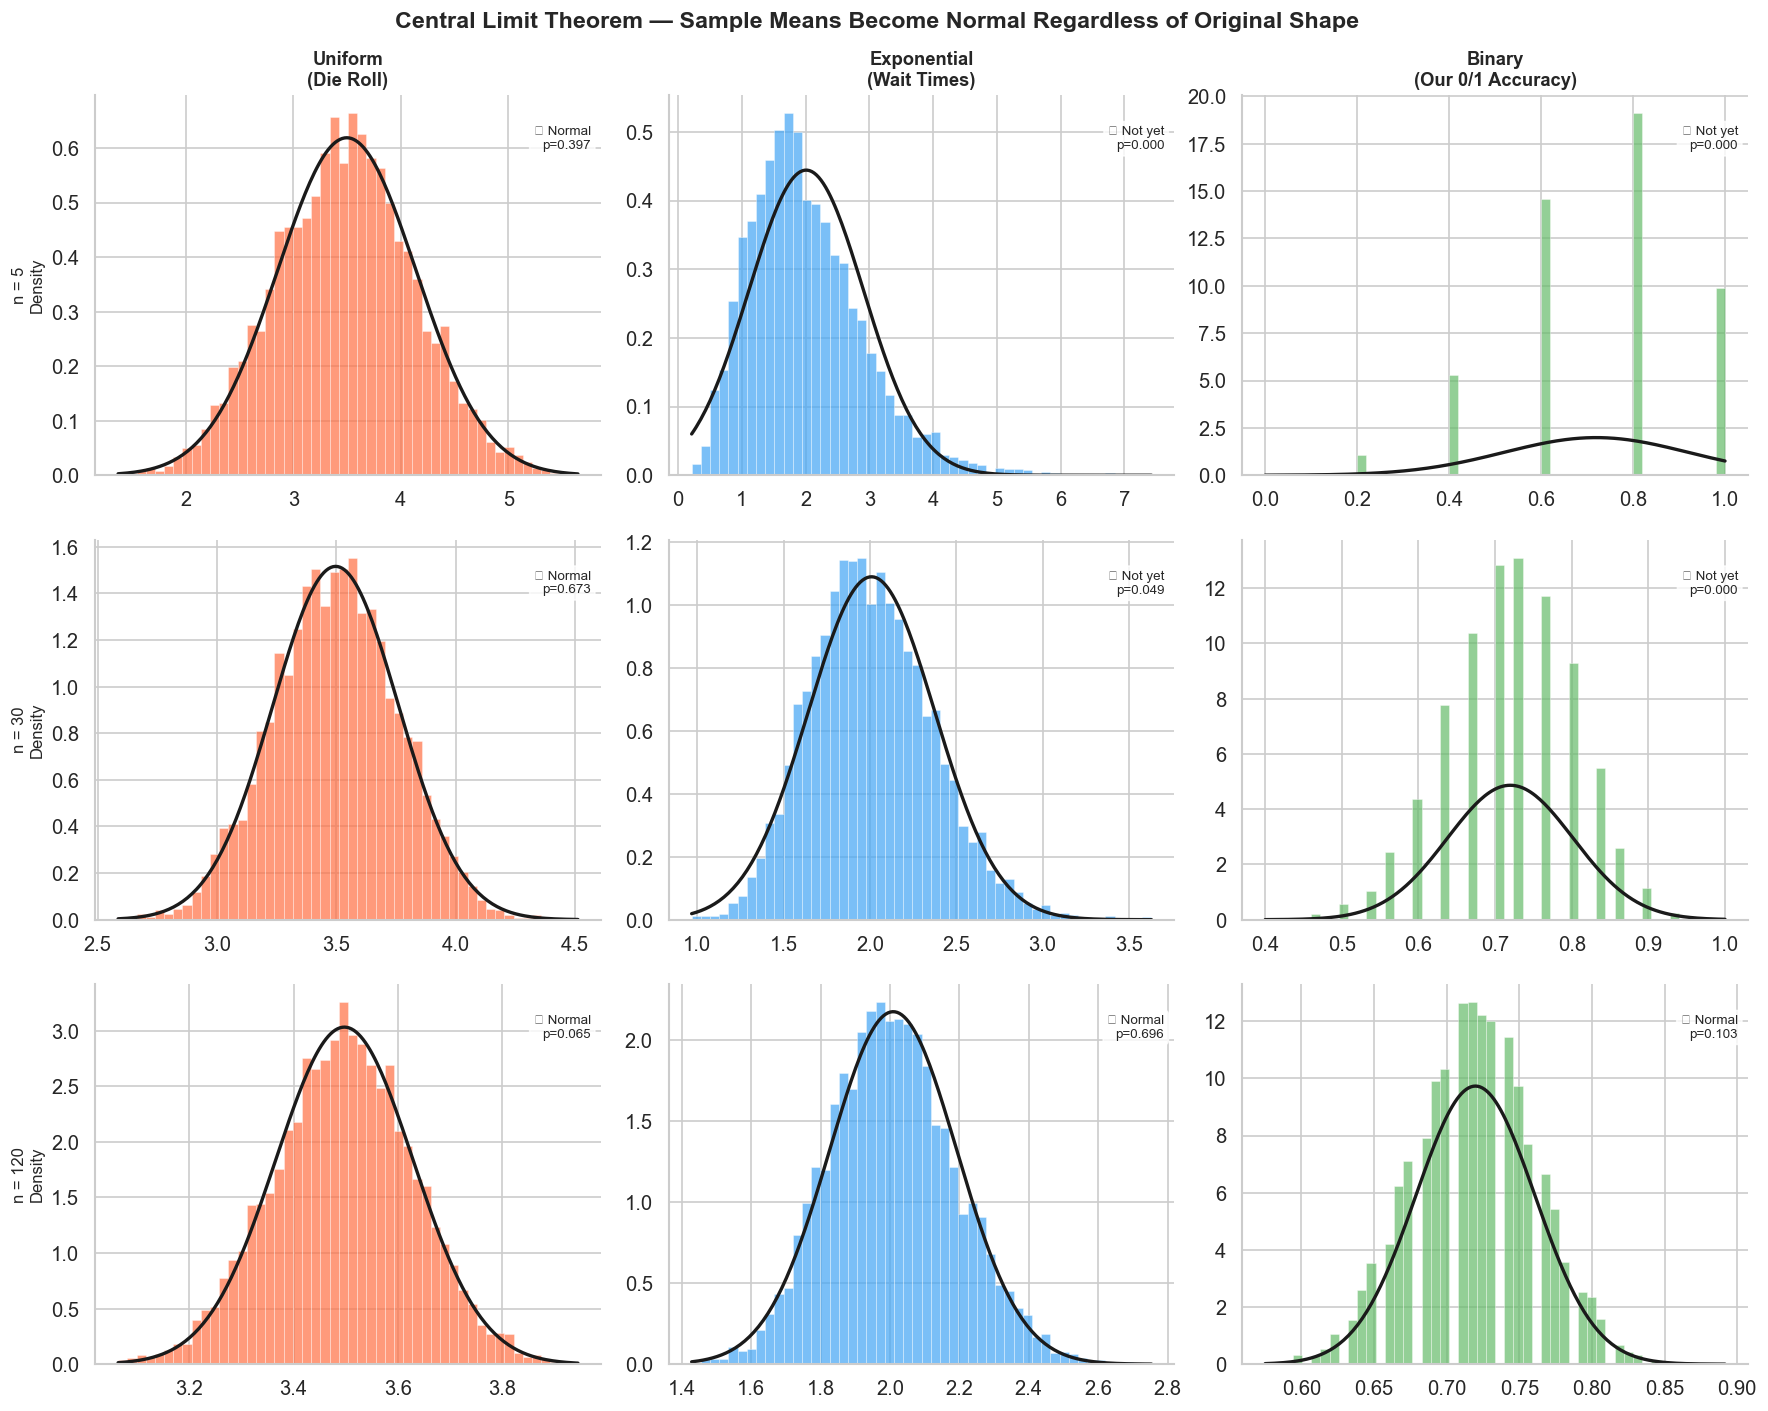


📌 KEY INSIGHT:
  - n=5:   Sample means still show the original distribution's shape
  - n=30:  Approaching normal (the classic textbook threshold)
  - n=120: Our experiment size. Fully normal by CLT. T-tests are VALID.


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 2.1 — CLT Demonstration
# ─────────────────────────────────────────────────────────────
#
# WHAT: Show that sample means are normally distributed regardless
#       of the original population shape.
# MOTIVE: Prove WHY t-tests work on our binary accuracy data.
#         Our raw data is 0 or 1 — clearly not normal.
#         But the MEAN of 120 such values IS approximately normal.
#         That's the CLT at work.

np.random.seed(SEED)

N_SIMULATIONS = 5000   # Number of times we repeat the experiment
                       # WHY 5000: Enough to show a smooth bell curve

# ── Three very different population distributions ─────────────
# We'll show CLT works on ALL of them
populations = {
    'Uniform\n(Die Roll)':      np.random.uniform(1, 6, 100_000),
    'Exponential\n(Wait Times)': np.random.exponential(scale=2, size=100_000),
    'Binary\n(Our 0/1 Accuracy)': np.random.binomial(1, 0.72, 100_000),
}

sample_sizes = [5, 30, 120]
# WHY these sizes? n=5 shows CLT is weak. n=30 is the classic threshold.
# n=120 is our actual experiment size — fully normal by CLT.

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(
    'Central Limit Theorem — Sample Means Become Normal Regardless of Original Shape',
    fontsize=14, fontweight='bold'
)

colors = ['#FF7043', '#42A5F5', '#66BB6A']

for col_idx, (pop_name, population) in enumerate(populations.items()):
    pop_mean = population.mean()
    pop_std  = population.std()

    for row_idx, n in enumerate(sample_sizes):
        ax = axes[row_idx, col_idx]

        # ── Simulate drawing N_SIMULATIONS samples of size n ────
        # WHY this approach:
        # np.random.choice draws a sample of size n from the population.
        # We do this N_SIMULATIONS times and record the MEAN each time.
        # This builds the "sampling distribution of the mean" — what CLT predicts.
        sample_means = [
            np.random.choice(population, size=n).mean()
            for _ in range(N_SIMULATIONS)
        ]
        sample_means = np.array(sample_means)

        # ── Plot the sampling distribution ──────────────────────
        ax.hist(sample_means, bins=50, color=colors[col_idx],
                alpha=0.7, density=True, edgecolor='white', linewidth=0.3)

        # ── Overlay theoretical normal curve ────────────────────
        # WHY: CLT predicts the sampling distribution should be Normal
        # with mean=pop_mean and std=pop_std/√n (Standard Error).
        # Overlaying the predicted curve shows HOW WELL CLT holds.
        theoretical_std = pop_std / np.sqrt(n)   # Standard Error formula
        x_range = np.linspace(sample_means.min(), sample_means.max(), 200)
        y_normal = stats.norm.pdf(x_range, pop_mean, theoretical_std)
        ax.plot(x_range, y_normal, 'k-', linewidth=2,
                label='Theoretical Normal')

        # ── Labels ─────────────────────────────────────────────
        if row_idx == 0:
            ax.set_title(pop_name, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f'n = {n}\nDensity', fontsize=10)

        # ── Normality check (Shapiro-Wilk) ──────────────────────
        # WHY Shapiro-Wilk: A formal test of normality.
        # p > 0.05 → can't reject normality → sample means are normal.
        # We use a subsample (500) because Shapiro-Wilk is slow on large arrays.
        _, p_normal = stats.shapiro(np.random.choice(sample_means, 500))
        normality_label = '✅ Normal' if p_normal > 0.05 else '⚠ Not yet'
        ax.text(0.98, 0.92, f'{normality_label}\np={p_normal:.3f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📌 KEY INSIGHT:")
print("  - n=5:   Sample means still show the original distribution's shape")
print("  - n=30:  Approaching normal (the classic textbook threshold)")
print(f"  - n=120: Our experiment size. Fully normal by CLT. T-tests are VALID.")

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 2.2 — Standard Error: The Precision of a Sample Mean
# ─────────────────────────────────────────────────────────────
#
# WHY Standard Error matters:
# Standard Error (SE) = std_dev / √n
# It measures HOW MUCH the sample mean varies from experiment to experiment.
# Small SE → your sample mean is a PRECISE estimate of the true mean.
# Large SE → your sample mean jumps around a lot → need more data.
#
# PRACTICAL IMPLICATION:
# If SE is large, even a real 8% accuracy improvement might be invisible
# in the noise. This is why sample size matters in A/B testing.
#
# ANALOGY: SE is the "margin of error" in a poll.
# "Candidate leads 52% ± 3%" — the ±3% is the SE.
# With more respondents, the margin shrinks.

print("══ STANDARD ERROR vs. SAMPLE SIZE ══")
print(f"Population std (Prompt A accuracy): σ ≈ {np.std(results_a):.4f}")
print()
print(f"{'Sample Size (n)':>18} {'Standard Error':>18} {'95% Margin of Error':>22}")
print("─" * 60)

pop_std = np.std(results_a)
for n in [10, 30, 50, 100, 120, 200, 500, 1000]:
    se = pop_std / np.sqrt(n)          # Standard Error formula
    moe = 1.96 * se                    # 95% confidence interval half-width
                                    # WHY 1.96: z-score at 95% confidence level
    bar = '█' * int(se * 200)
    highlight = " ← Our experiment" if n == 120 else ""
    print(f"{n:>18,} {se:>18.4f} {moe:>22.4f}{highlight}")

print()
print(f"Our SE at n=120: {pop_std/np.sqrt(120):.4f}")
print(f"95% margin of error: ±{1.96 * pop_std/np.sqrt(120):.4f} ({1.96 * pop_std/np.sqrt(120)*100:.1f} percentage points)")
print("Meaning: our observed accuracy is the TRUE accuracy ± this margin, 95% of the time.")

══ STANDARD ERROR vs. SAMPLE SIZE ══
Population std (Prompt A accuracy): σ ≈ 0.4506

   Sample Size (n)     Standard Error    95% Margin of Error
────────────────────────────────────────────────────────────
                10             0.1425                 0.2793
                30             0.0823                 0.1613
                50             0.0637                 0.1249
               100             0.0451                 0.0883
               120             0.0411                 0.0806 ← Our experiment
               200             0.0319                 0.0625
               500             0.0202                 0.0395
             1,000             0.0142                 0.0279

Our SE at n=120: 0.0411
95% margin of error: ±0.0806 (8.1 percentage points)
Meaning: our observed accuracy is the TRUE accuracy ± this margin, 95% of the time.


---
## Section 3 — P-values & Statistical Significance

### Topic
A **p-value** is the probability of observing results as extreme as yours (or more extreme) **IF the null hypothesis were true**.

### The Hypothesis Testing Framework
Every hypothesis test has two competing hypotheses:

| Hypothesis | Symbol | Statement |
|------------|--------|-----------|
| **Null Hypothesis** | H₀ | "There is NO difference. Any observed gap is random noise." |
| **Alternative Hypothesis** | H₁ | "There IS a real difference." |

For our experiment:
- **H₀:** Prompt A and Prompt B produce the same accuracy. (μ_A = μ_B)
- **H₁:** Prompt B produces higher accuracy than Prompt A. (μ_B > μ_A)

### What P-value Actually Means
- **p = 0.03** → "If H₀ were true (no real difference), there is only a 3% chance of seeing a gap this large or larger just by random chance."
- **p = 0.60** → "A gap this large or larger would occur 60% of the time purely by chance. Not convincing evidence."

### Significance Level (α)
We pre-set a **threshold** α (typically 0.05) before the test:
- **p < α (0.05):** Reject H₀ → The difference is statistically significant
- **p ≥ α (0.05):** Fail to reject H₀ → Insufficient evidence

### Analogy ⚖️
> **P-value is like a courtroom standard of proof.**
> H₀ is "innocent until proven guilty." The p-value measures how suspicious the evidence is.
> p=0.03 → only 3% chance this evidence exists if the defendant is truly innocent.
> We convict (reject H₀) when evidence is strong enough (p < α = 0.05).
> We never "prove innocence" — we just say "insufficient evidence to convict."

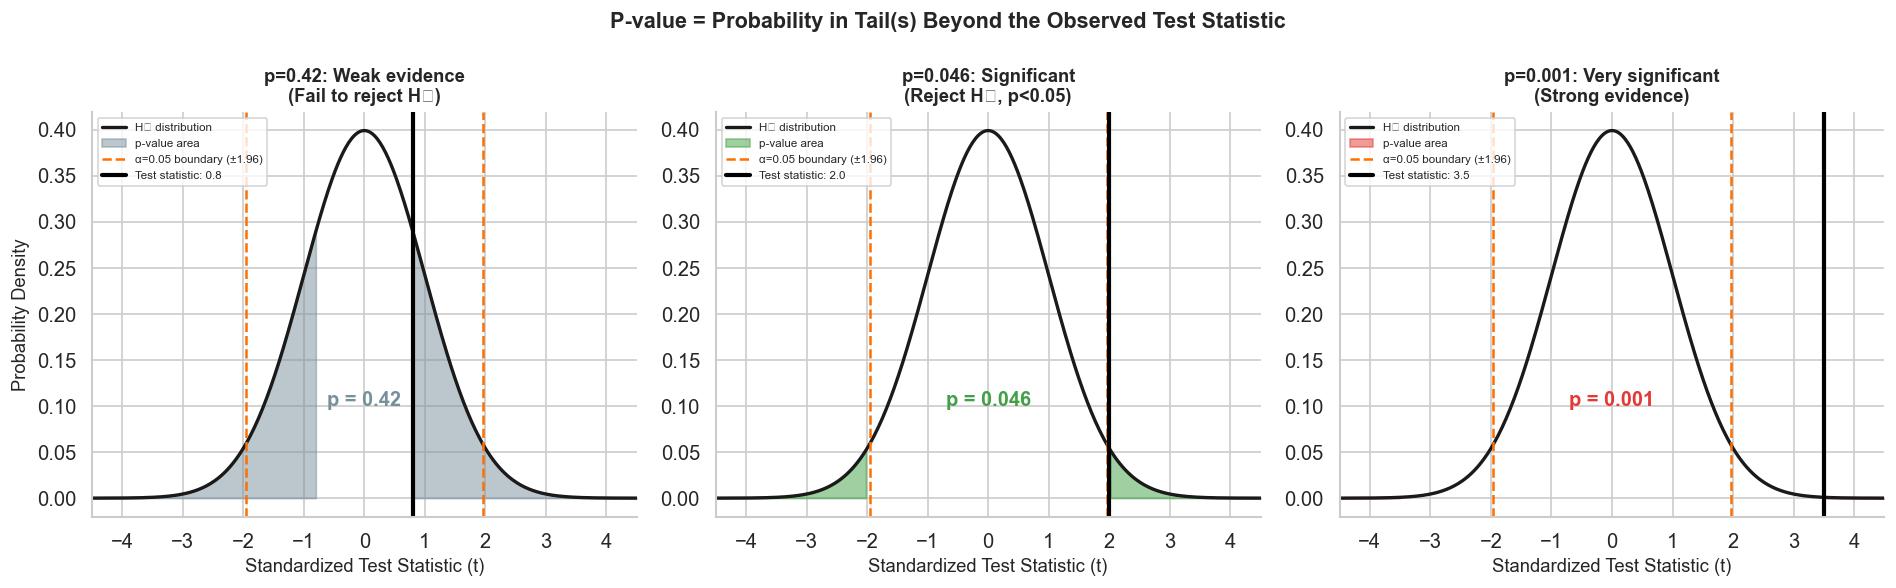


📌 KEY INSIGHT:
  The p-value is the AREA in the shaded tails.
  When the shaded area is small (p < 0.05), the result is statistically significant.
  The critical boundary lines show where α=0.05 cuts off the tail.


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 3.1 — P-value Visualized
# ─────────────────────────────────────────────────────────────
#
# WHAT: Visualize what a p-value actually IS on a distribution.
# MOTIVE: Most people say "p < 0.05 is significant" without knowing
# what the p-value geometrically represents.
# The p-value is the SHADED AREA in the tail(s) beyond your test statistic.
#
# ANALOGY: If you throw a ball and claim it traveled further than anyone else,
# the p-value is the fraction of normal throws that travel THAT far or further.
# If only 2% of normal throws go that far, your throw is suspicious (p=0.02).

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'P-value = Probability in Tail(s) Beyond the Observed Test Statistic',
    fontsize=13, fontweight='bold'
)

scenarios = [
    {'t_stat': 0.8,  'p': 0.42,  'label': 'p=0.42: Weak evidence\n(Fail to reject H₀)',  'color': '#78909C'},
    {'t_stat': 2.0,  'p': 0.046, 'label': 'p=0.046: Significant\n(Reject H₀, p<0.05)',  'color': '#43A047'},
    {'t_stat': 3.5,  'p': 0.001, 'label': 'p=0.001: Very significant\n(Strong evidence)', 'color': '#E53935'},
]

x = np.linspace(-4.5, 4.5, 400)
y = stats.norm.pdf(x, 0, 1)   # Standard normal distribution (H₀ distribution)

for ax, s in zip(axes, scenarios):
    t = s['t_stat']
    color = s['color']

    # Draw the null distribution
    ax.plot(x, y, 'k-', linewidth=2, label='H₀ distribution')

    # ── Shade the rejection region (two-tailed) ──────────────
    # WHY fill_between with conditions:
    # We shade the area beyond |t_stat| in BOTH tails for a two-tailed test.
    # This shaded area = the p-value.
    ax.fill_between(x, y, where=(x >= t),  color=color, alpha=0.5, label=f'p-value area')
    ax.fill_between(x, y, where=(x <= -t), color=color, alpha=0.5)

    # ── Critical value lines (α=0.05 threshold) ──────────────
    # WHY ±1.96: For a standard normal, 95% of data falls between -1.96 and +1.96.
    # Values beyond ±1.96 → in the critical (rejection) region.
    critical = 1.96  # z-score at α=0.05 (two-tailed)
    ax.axvline( critical, color='#FF6F00', linewidth=1.5,
               linestyle='--', label=f'α=0.05 boundary (±{critical})')
    ax.axvline(-critical, color='#FF6F00', linewidth=1.5, linestyle='--')

    # ── Test statistic marker ────────────────────────────────
    ax.axvline(t, color='black', linewidth=2.5, linestyle='-',
               label=f'Test statistic: {t}')

    ax.set_title(s['label'], fontsize=11)
    ax.set_xlabel('Standardized Test Statistic (t)')
    if ax == axes[0]:
        ax.set_ylabel('Probability Density')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_xlim(-4.5, 4.5)

    # ── Annotate p-value ─────────────────────────────────────
    ax.text(0, 0.1, f'p = {s["p"]}', transform=ax.transData,
            ha='center', fontsize=12, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

print("\n📌 KEY INSIGHT:")
print("  The p-value is the AREA in the shaded tails.")
print("  When the shaded area is small (p < 0.05), the result is statistically significant.")
print("  The critical boundary lines show where α=0.05 cuts off the tail.")

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 3.2 — Common P-value Misconceptions
# ─────────────────────────────────────────────────────────────
#
# MOTIVE: These misconceptions appear in data science interviews
# and in real research papers. Getting them right separates
# junior and senior data scientists.

print("══ P-VALUE: WHAT IT IS vs. WHAT IT IS NOT ══")
print()

misconceptions = [
    {
        'wrong':   '❌ p=0.03 means there is a 3% chance H₀ is true',
        'correct': '✅ p=0.03 means: IF H₀ were true, there is a 3% chance of\n'
                   '   seeing a result this extreme by random chance.',
        'note':    'p-values are about DATA, not about hypotheses being true/false.'
    },
    {
        'wrong':   '❌ p < 0.05 means the effect is LARGE or IMPORTANT',
        'correct': '✅ p < 0.05 means the effect is REAL (not noise).\n'
                   '   With n=10,000, even a 0.1% improvement gives p < 0.05.\n'
                   '   Always report EFFECT SIZE, not just significance.',
        'note':    'Statistical significance ≠ Practical significance.'
    },
    {
        'wrong':   '❌ p > 0.05 PROVES H₀ (no difference exists)',
        'correct': '✅ p > 0.05 means insufficient evidence to reject H₀.\n'
                   '   Maybe the difference is real but your sample is too small.\n'
                   '   Absence of evidence ≠ Evidence of absence.',
        'note':    'Always consider statistical POWER when p > 0.05.'
    },
    {
        'wrong':   '❌ Running the test 20 times and reporting the one p < 0.05 is fine',
        'correct': '✅ This is p-hacking. With α=0.05, you expect 1 false positive\n'
                   '   per 20 tests by chance alone. Use Bonferroni correction:\n'
                   '   α_corrected = 0.05 / number_of_tests',
        'note':    'Always pre-register your hypothesis before seeing the data.'
    },
]

for i, m in enumerate(misconceptions, 1):
    print(f"MISCONCEPTION {i}:")
    print(f"  {m['wrong']}")
    print(f"  {m['correct']}")
    print(f"  💡 Note: {m['note']}")
    print()

══ P-VALUE: WHAT IT IS vs. WHAT IT IS NOT ══

MISCONCEPTION 1:
  ❌ p=0.03 means there is a 3% chance H₀ is true
  ✅ p=0.03 means: IF H₀ were true, there is a 3% chance of
   seeing a result this extreme by random chance.
  💡 Note: p-values are about DATA, not about hypotheses being true/false.

MISCONCEPTION 2:
  ❌ p < 0.05 means the effect is LARGE or IMPORTANT
  ✅ p < 0.05 means the effect is REAL (not noise).
   With n=10,000, even a 0.1% improvement gives p < 0.05.
   Always report EFFECT SIZE, not just significance.
  💡 Note: Statistical significance ≠ Practical significance.

MISCONCEPTION 3:
  ❌ p > 0.05 PROVES H₀ (no difference exists)
  ✅ p > 0.05 means insufficient evidence to reject H₀.
   Maybe the difference is real but your sample is too small.
   Absence of evidence ≠ Evidence of absence.
  💡 Note: Always consider statistical POWER when p > 0.05.

MISCONCEPTION 4:
  ❌ Running the test 20 times and reporting the one p < 0.05 is fine
  ✅ This is p-hacking. With α=0.05, you

---
## Section 4 — One-Sample T-Test

### Topic
A **one-sample t-test** tests whether the mean of one sample significantly differs from a known or hypothesized **target value**.

### When to Use It
- "Does our model's average confidence score differ from 0.75 (our baseline target)?"
- "Is our classifier's accuracy significantly above 70% (the minimum acceptable threshold)?"
- "Is average response latency significantly above the 200ms SLA?"

### How It Works
1. State H₀: sample mean = target value (μ = μ₀)
2. Compute the **t-statistic**: `t = (x̄ - μ₀) / (s / √n)`
   - x̄ = sample mean, μ₀ = target, s = sample std dev, n = sample size
3. Look up the p-value for this t-statistic with `df = n - 1` degrees of freedom
4. If p < α → reject H₀

### Analogy 🎯
> **The dart-throw accuracy test.**
> Your team claims their new AI targeting system hits the bullseye 80% of the time.
> You observe 120 throws and record hits. The one-sample t-test asks:
> "Is our observed hit rate statistically consistent with 80%, or is it significantly different?"

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 4.1 — One-Sample T-Test: Does Prompt A Meet the Target?
# ─────────────────────────────────────────────────────────────
#
# BUSINESS QUESTION:
# The product team says the classifier must achieve >= 75% accuracy
# to go to production. Prompt A was observed at some accuracy level.
# Is Prompt A's performance statistically consistent with 75%?
# Or is it significantly BELOW (i.e., it fails the threshold)?
#
# H₀: μ_confidence_A = 0.75  (Prompt A meets the threshold on average)
# H₁: μ_confidence_A ≠ 0.75  (two-tailed: could be above OR below)

TARGET_THRESHOLD = 0.75   # Production minimum acceptable mean confidence
ALPHA = 0.05              # Significance level (5%)

# ── Run the Test ─────────────────────────────────────────────
# scipy.stats.ttest_1samp(a=data, popmean=target)
# WHY ttest_1samp: Compares our SAMPLE mean to a fixed KNOWN value.
# It internally computes: t = (x̄ - μ₀) / (s/√n)
t_stat, p_value = ttest_1samp(a=scores_a, popmean=TARGET_THRESHOLD)

# ── Manual Verification ──────────────────────────────────────
x_bar = scores_a.mean()
s     = scores_a.std(ddof=1)
n     = len(scores_a)
t_manual = (x_bar - TARGET_THRESHOLD) / (s / np.sqrt(n))

print("══ ONE-SAMPLE T-TEST ══")
print(f"H₀: Mean confidence of Prompt A = {TARGET_THRESHOLD} (meets production threshold)")
print(f"H₁: Mean confidence of Prompt A ≠ {TARGET_THRESHOLD}")
print(f"Significance level α = {ALPHA}")
print()
print(f"── Sample Statistics ──")
print(f"  Sample mean (x̄):    {x_bar:.4f}")
print(f"  Sample std dev (s): {s:.4f}")
print(f"  Sample size (n):    {n}")
print()
print(f"── T-Statistic Formula: t = (x̄ - μ₀) / (s/√n) ──")
print(f"  t = ({x_bar:.4f} - {TARGET_THRESHOLD}) / ({s:.4f} / √{n})")
print(f"  t = {x_bar - TARGET_THRESHOLD:.4f} / {s/np.sqrt(n):.4f}")
print(f"  t = {t_manual:.4f}")
print()
print(f"── Results ──")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_value:.4f}")
print(f"  Degrees of freedom: {n - 1}")
print()

# ── Decision ─────────────────────────────────────────────────
if p_value < ALPHA:
    print(f"  ✅ REJECT H₀ (p={p_value:.4f} < α={ALPHA})")
    direction = "above" if t_stat > 0 else "below"
    print(f"  Conclusion: Prompt A's mean confidence is significantly {direction} {TARGET_THRESHOLD}.")
else:
    print(f"  ⚪ FAIL TO REJECT H₀ (p={p_value:.4f} ≥ α={ALPHA})")
    print(f"  Conclusion: Insufficient evidence that Prompt A differs from the {TARGET_THRESHOLD} target.")

# ── 95% Confidence Interval ──────────────────────────────────
# WHY confidence interval?
# A p-value only says "significant or not". A CI gives you a RANGE
# for the true mean — much more informative for business decisions.
ci = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=x_bar,
    scale=s/np.sqrt(n)
)
print()
print(f"  95% Confidence Interval: [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"  Interpretation: We are 95% confident the TRUE mean confidence is between {ci[0]:.3f} and {ci[1]:.3f}.")
within = ci[0] <= TARGET_THRESHOLD <= ci[1]
print(f"  Target ({TARGET_THRESHOLD}) is {'INSIDE' if within else 'OUTSIDE'} the 95% CI.")

══ ONE-SAMPLE T-TEST ══
H₀: Mean confidence of Prompt A = 0.75 (meets production threshold)
H₁: Mean confidence of Prompt A ≠ 0.75
Significance level α = 0.05

── Sample Statistics ──
  Sample mean (x̄):    0.7164
  Sample std dev (s): 0.1818
  Sample size (n):    120

── T-Statistic Formula: t = (x̄ - μ₀) / (s/√n) ──
  t = (0.7164 - 0.75) / (0.1818 / √120)
  t = -0.0336 / 0.0166
  t = -2.0233

── Results ──
  t-statistic: -2.0233
  p-value:     0.0453
  Degrees of freedom: 119

  ✅ REJECT H₀ (p=0.0453 < α=0.05)
  Conclusion: Prompt A's mean confidence is significantly below 0.75.

  95% Confidence Interval: [0.6836, 0.7493]
  Interpretation: We are 95% confident the TRUE mean confidence is between 0.684 and 0.749.
  Target (0.75) is OUTSIDE the 95% CI.


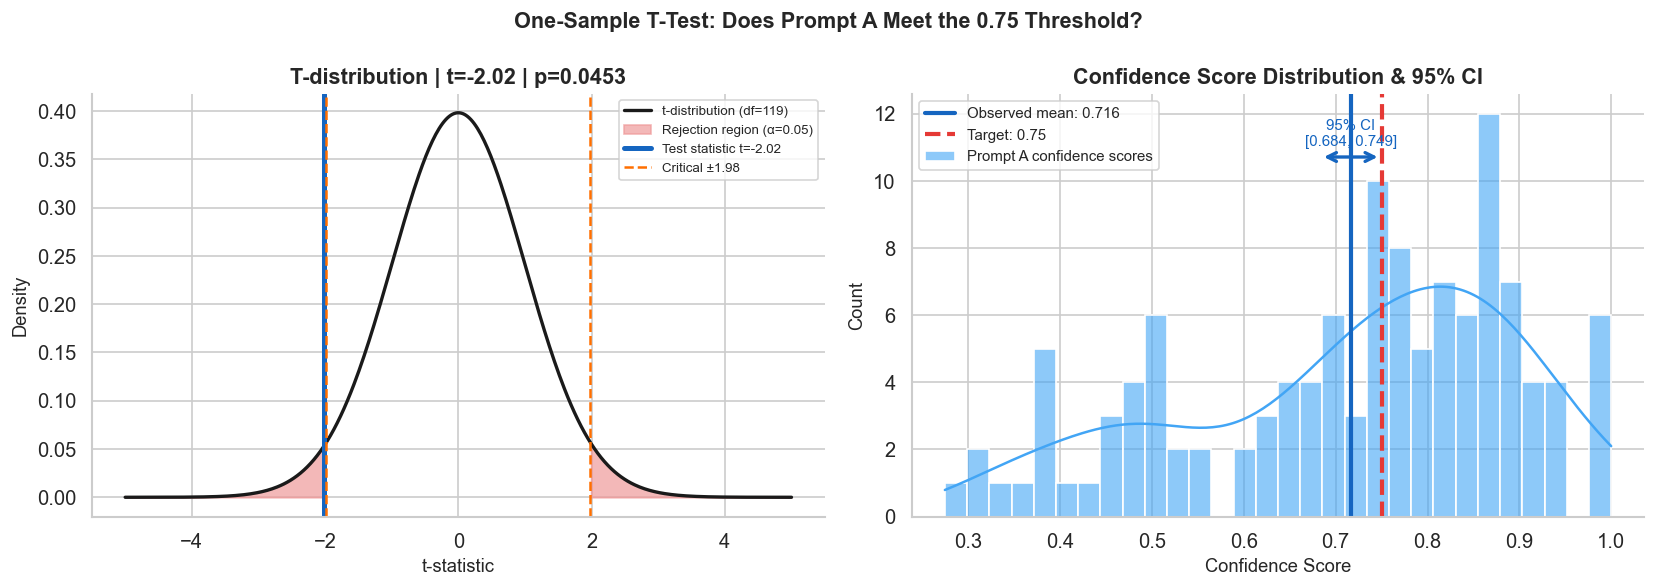

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 4.2 — Visualize the One-Sample T-Test
# ─────────────────────────────────────────────────────────────
#
# WHAT: Show the t-distribution, where our test statistic falls,
# and the rejection regions.
# MOTIVE: Make the p-value tangible — not just a number, but a geometry.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('One-Sample T-Test: Does Prompt A Meet the 0.75 Threshold?',
             fontsize=13, fontweight='bold')

# ── LEFT: T-Distribution with rejection regions ──────────────
df_t = n - 1  # Degrees of freedom
x_t  = np.linspace(-5, 5, 400)
y_t  = stats.t.pdf(x_t, df=df_t)

ax1.plot(x_t, y_t, 'k-', linewidth=2, label=f't-distribution (df={df_t})')

# Shade the critical regions (α/2 = 0.025 in each tail for two-tailed)
critical_t = stats.t.ppf(1 - ALPHA/2, df=df_t)  # Critical value at α=0.05 (two-tailed)
# WHY ALPHA/2: Two-tailed test splits α equally between both tails.

ax1.fill_between(x_t, y_t, where=(x_t >= critical_t),
                 color='#EF9A9A', alpha=0.7, label=f'Rejection region (α={ALPHA})')
ax1.fill_between(x_t, y_t, where=(x_t <= -critical_t),
                 color='#EF9A9A', alpha=0.7)

# Mark test statistic
ax1.axvline(t_stat, color='#1565C0', linewidth=3,
            label=f'Test statistic t={t_stat:.2f}')
ax1.axvline(critical_t,  color='#FF6F00', linewidth=1.5, linestyle='--',
            label=f'Critical ±{critical_t:.2f}')
ax1.axvline(-critical_t, color='#FF6F00', linewidth=1.5, linestyle='--')

ax1.set_title(f'T-distribution | t={t_stat:.2f} | p={p_value:.4f}')
ax1.set_xlabel('t-statistic')
ax1.set_ylabel('Density')
ax1.legend(fontsize=8)

# ── RIGHT: Confidence interval visualization ──────────────────
# WHAT: Show the sample distribution, the mean, and the 95% CI.
# WHY: This is what a businessperson understands — "our estimate and its range."
sns.histplot(scores_a, bins=30, kde=True, color='#42A5F5', alpha=0.6,
             ax=ax2, label='Prompt A confidence scores')

ax2.axvline(x_bar, color='#1565C0', linewidth=2.5,
            label=f'Observed mean: {x_bar:.3f}')
ax2.axvline(TARGET_THRESHOLD, color='#E53935', linewidth=2.5, linestyle='--',
            label=f'Target: {TARGET_THRESHOLD}')

# Draw CI bracket
y_bracket = ax2.get_ylim()[1] * 0.85
ax2.annotate('', xy=(ci[1], y_bracket), xytext=(ci[0], y_bracket),
             arrowprops=dict(arrowstyle='<->', color='#1565C0', lw=2))
ax2.text((ci[0]+ci[1])/2, y_bracket * 1.03,
         f'95% CI\n[{ci[0]:.3f}, {ci[1]:.3f}]',
         ha='center', fontsize=9, color='#1565C0')

ax2.set_title('Confidence Score Distribution & 95% CI')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 5 — Two-Sample Independent T-Test

### Topic
The **two-sample (independent) t-test** tests whether the means of **two independent groups** are significantly different.

### When to Use It
- "Does Prompt A produce higher confidence scores than Prompt B?"
- "Does Model A outperform Model B on average?"
- "Do users in Dhaka click through at a higher rate than users in Chittagong?"

### The Formula
```
         x̄_A - x̄_B
t = ────────────────────────
     √(s²_A/n_A + s²_B/n_B)
```
- Numerator: Observed difference in means
- Denominator: Pooled standard error (uncertainty in the difference)

### Key Assumption: Independence
The two samples must be **independent** — no message is evaluated by both prompts. If the same messages were evaluated by both prompts (paired design), you'd use a **paired t-test** instead.

### Analogy ⚔️
> **Two separate classrooms take the same exam.**
> Class A used the old textbook, Class B used the new textbook.
> The two-sample t-test asks: "Did Class B truly score higher, or did random variation explain the gap?"
> The classes are **independent** — no student is in both.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 5.1 — Two-Sample T-Test: Prompt A vs. Prompt B
# ─────────────────────────────────────────────────────────────
#
# H₀: μ_B - μ_A = 0  (Prompt B and Prompt A produce the same mean confidence)
# H₁: μ_B > μ_A      (Prompt B produces HIGHER confidence — one-tailed)
#
# WHY one-tailed here?
# We specifically hypothesize that the NEW prompt is BETTER.
# A two-tailed test would also detect if Prompt B is WORSE,
# but our business question is directional.
#
# IMPORTANT: Decide one-tailed vs two-tailed BEFORE seeing the data.
# Switching after seeing results is p-hacking.

# ── Run the test ─────────────────────────────────────────────
# WHY equal_var=False (Welch's t-test)?
# The standard t-test assumes EQUAL variances in both groups.
# Welch's version does NOT make this assumption — more robust.
# Welch's test should always be your default unless you have strong
# prior knowledge that variances are equal.
# ANALOGY: Welch's is like adjusting a recipe for different oven temperatures.
# Even if the ingredients are the same, the conditions may differ.
t_stat_2, p_value_2tail = ttest_ind(scores_b, scores_a, equal_var=False)

# For one-tailed test (H₁: μ_B > μ_A):
# If t > 0 (meaning B > A in our data), the one-tailed p = two-tailed p / 2
# WHY /2: A one-tailed test only cares about one tail, not both.
p_value_1tail = p_value_2tail / 2 if t_stat_2 > 0 else 1 - p_value_2tail / 2

# ── Compute effect size (Cohen's d) ──────────────────────────
# WHY effect size?
# p-value tells you IF the effect exists. Effect size tells you HOW BIG it is.
# Cohen's d = (μ_B - μ_A) / pooled_std
# Small: d < 0.2, Medium: 0.2–0.8, Large: d > 0.8
pooled_std = np.sqrt((scores_a.std(ddof=1)**2 + scores_b.std(ddof=1)**2) / 2)
cohens_d   = (scores_b.mean() - scores_a.mean()) / pooled_std

print("══ TWO-SAMPLE T-TEST (Welch's) ══")
print(f"H₀: μ_B = μ_A  (no difference between prompts)")
print(f"H₁: μ_B > μ_A  (Prompt B is better — one-tailed)")
print(f"Significance level α = {ALPHA}")
print()
print(f"{'':25s} {'Prompt A':>12} {'Prompt B':>12} {'Difference':>12}")
print("─" * 65)
print(f"{'Sample size':25s} {len(scores_a):>12,} {len(scores_b):>12,}")
print(f"{'Mean confidence':25s} {scores_a.mean():>12.4f} {scores_b.mean():>12.4f} {scores_b.mean()-scores_a.mean():>+12.4f}")
print(f"{'Std deviation':25s} {scores_a.std(ddof=1):>12.4f} {scores_b.std(ddof=1):>12.4f}")
print(f"{'Observed accuracy':25s} {results_a.mean():>12.1%} {results_b.mean():>12.1%} {results_b.mean()-results_a.mean():>+12.1%}")
print()
print(f"── Test Results ──")
print(f"  t-statistic:      {t_stat_2:.4f}")
print(f"  p-value (2-tail): {p_value_2tail:.4f}")
print(f"  p-value (1-tail): {p_value_1tail:.4f}")
print(f"  Cohen's d:        {cohens_d:.4f}",
      f"→ {'Small' if abs(cohens_d)<0.2 else 'Medium' if abs(cohens_d)<0.8 else 'Large'} effect")
print()

if p_value_1tail < ALPHA:
    print(f"  ✅ REJECT H₀ (p={p_value_1tail:.4f} < α={ALPHA})")
    print(f"  Conclusion: Prompt B produces statistically significantly HIGHER confidence scores.")
    print(f"  The {scores_b.mean()-scores_a.mean():+.4f} improvement is NOT due to random chance.")
else:
    print(f"  ⚪ FAIL TO REJECT H₀ (p={p_value_1tail:.4f} ≥ α={ALPHA})")
    print(f"  Conclusion: Insufficient evidence that Prompt B is better.")
    print(f"  The observed improvement could be random chance.")

══ TWO-SAMPLE T-TEST (Welch's) ══
H₀: μ_B = μ_A  (no difference between prompts)
H₁: μ_B > μ_A  (Prompt B is better — one-tailed)
Significance level α = 0.05

                              Prompt A     Prompt B   Difference
─────────────────────────────────────────────────────────────────
Sample size                        120          120
Mean confidence                 0.7164       0.7912      +0.0748
Std deviation                   0.1818       0.1864
Observed accuracy                71.7%        81.7%       +10.0%

── Test Results ──
  t-statistic:      3.1452
  p-value (2-tail): 0.0019
  p-value (1-tail): 0.0009
  Cohen's d:        0.4060 → Medium effect

  ✅ REJECT H₀ (p=0.0009 < α=0.05)
  Conclusion: Prompt B produces statistically significantly HIGHER confidence scores.
  The +0.0748 improvement is NOT due to random chance.


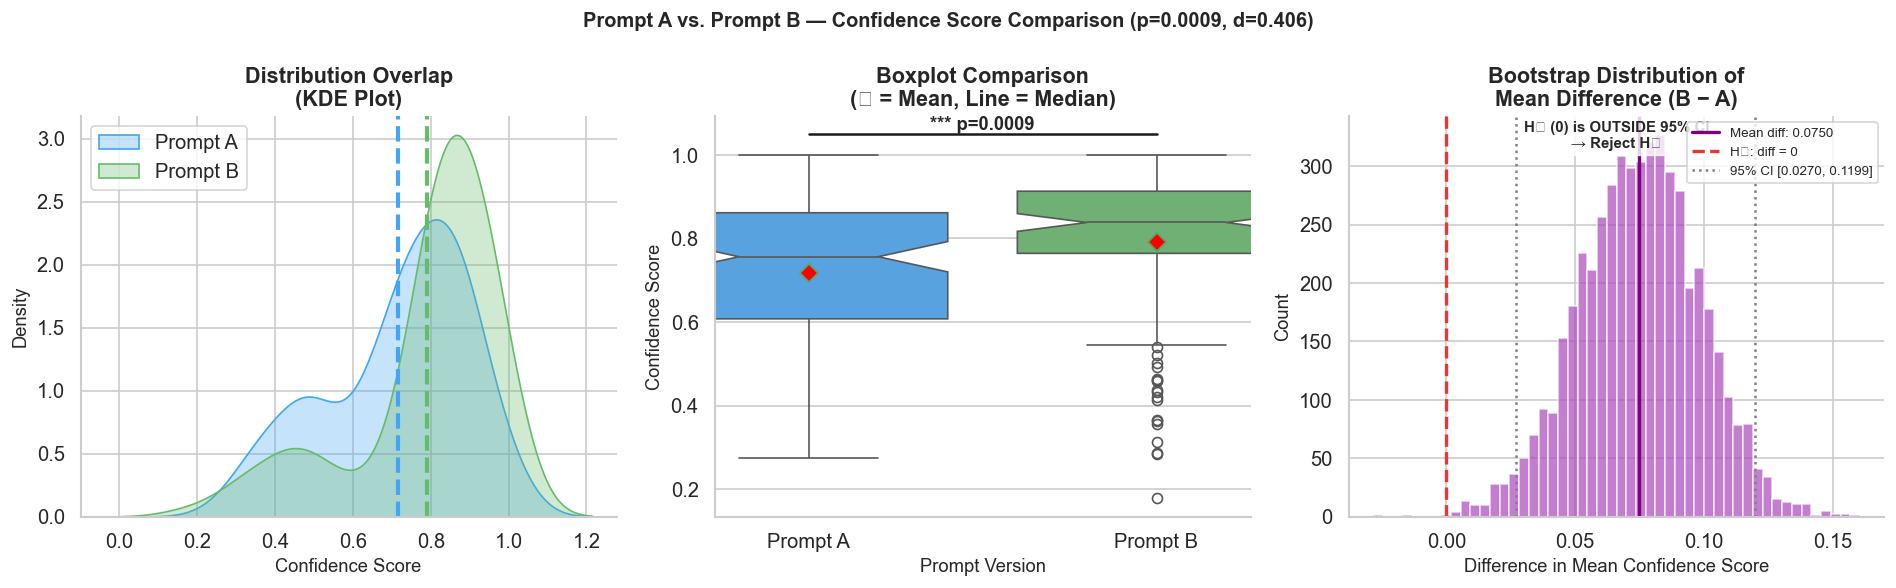

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 5.2 — Visualize Two-Sample Comparison
# ─────────────────────────────────────────────────────────────
#
# WHAT: Three complementary views of the same A vs. B comparison.
# MOTIVE: Never present just the p-value. Always show the data.
# Each chart type reveals something different.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Prompt A vs. Prompt B — Confidence Score Comparison (p={p_value_1tail:.4f}, d={cohens_d:.3f})',
             fontsize=12, fontweight='bold')

palette = {'Prompt A': '#42A5F5', 'Prompt B': '#66BB6A'}
df_plot = pd.DataFrame({
    'confidence': np.concatenate([scores_a, scores_b]),
    'prompt':     ['Prompt A'] * N_A + ['Prompt B'] * N_B
})

# ── LEFT: Overlapping KDE distributions ──────────────────────
# WHAT: Shows the full distribution shape of both groups.
# WHY: You can see HOW MUCH the distributions overlap.
# Large overlap → small effect. Minimal overlap → large effect.
# This is what Cohen's d measures numerically.
ax = axes[0]
for prompt, color in palette.items():
    data = df_plot[df_plot['prompt'] == prompt]['confidence']
    sns.kdeplot(data=data, ax=ax, label=prompt, fill=True, alpha=0.3, color=color)
    ax.axvline(data.mean(), color=color, linewidth=2.5, linestyle='--')

ax.set_title('Distribution Overlap\n(KDE Plot)')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Density')
ax.legend()

# ── MIDDLE: Boxplot comparison ────────────────────────────────
# WHAT: Five-number summary side-by-side.
# WHY: Immediately shows median, spread, and outliers for both groups.
# The NON-OVERLAPPING notches indicate significant medians difference.
ax = axes[1]
sns.boxplot(data=df_plot, x='prompt', y='confidence',
            palette=palette, notch=True,
            # WHY notch=True: Notches show 95% CI around the median.
            # Non-overlapping notches → medians are significantly different.
            ax=ax,
            showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 8})
ax.set_title('Boxplot Comparison\n(◆ = Mean, Line = Median)')
ax.set_xlabel('Prompt Version')
ax.set_ylabel('Confidence Score')

# Significance annotation
y_max = df_plot['confidence'].max() * 1.05
ax.plot([0, 1], [y_max, y_max], 'k-', linewidth=1.5)
sig_label = '***' if p_value_1tail < 0.001 else ('**' if p_value_1tail < 0.01 else '*')
ax.text(0.5, y_max * 1.01, f'{sig_label} p={p_value_1tail:.4f}',
        ha='center', fontsize=11, fontweight='bold')

# ── RIGHT: Bootstrap confidence interval of the difference ────
# WHAT: Simulate the sampling distribution of (μ_B - μ_A) by resampling.
# WHY bootstrap?
# The t-test gives us the p-value based on theoretical distributions.
# Bootstrap gives the same answer empirically — by actually resampling
# 5000 times and computing the difference each time.
# If the 95% CI of the bootstrap difference does NOT include 0 → significant.
# Bootstrap is more robust for small samples or non-normal data.
ax = axes[2]
np.random.seed(SEED)
boot_diffs = [
    np.random.choice(scores_b, size=N_B, replace=True).mean() -
    np.random.choice(scores_a, size=N_A, replace=True).mean()
    for _ in range(5000)
]
boot_diffs = np.array(boot_diffs)

ax.hist(boot_diffs, bins=50, color='#AB47BC', alpha=0.7, edgecolor='white')
ci_boot = np.percentile(boot_diffs, [2.5, 97.5])  # 95% CI from bootstrap
ax.axvline(boot_diffs.mean(), color='purple', linewidth=2,
           label=f'Mean diff: {boot_diffs.mean():.4f}')
ax.axvline(0, color='#E53935', linewidth=2, linestyle='--',
           label='H₀: diff = 0')
ax.axvline(ci_boot[0], color='gray', linewidth=1.5, linestyle=':',
           label=f'95% CI [{ci_boot[0]:.4f}, {ci_boot[1]:.4f}]')
ax.axvline(ci_boot[1], color='gray', linewidth=1.5, linestyle=':')

h0_in_ci = ci_boot[0] <= 0 <= ci_boot[1]
ax.text(0.5, 0.92, f'H₀ (0) is {"INSIDE" if h0_in_ci else "OUTSIDE"} 95% CI\n→ {"Fail to reject" if h0_in_ci else "Reject"} H₀',
        transform=ax.transAxes, ha='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('Bootstrap Distribution of\nMean Difference (B − A)')
ax.set_xlabel('Difference in Mean Confidence Score')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Section 6 — ANOVA (Analysis of Variance)

### Topic
**ANOVA** (Analysis of Variance) tests whether the means of **three or more groups** are significantly different from each other.

### Why Not Just Run Multiple T-Tests?
If you test 4 groups pairwise, you run C(4,2) = 6 t-tests.
With α=0.05 per test, the probability of at least one false positive:
```
P(at least one false positive) = 1 - (1 - 0.05)^6 = 26.5%
```
That's a 26.5% chance of being wrong — not 5%. This is the **multiple comparisons problem**.
ANOVA tests ALL groups simultaneously with one test, keeping the Type I error at α=0.05.

### How ANOVA Works
ANOVA decomposes total variance into:
- **Between-group variance:** How much do group MEANS differ from the overall mean? (Signal)
- **Within-group variance:** How much do individual values differ from their group mean? (Noise)

```
F-statistic = Between-group variance / Within-group variance
            = Signal / Noise
```
Large F → means differ more than chance → reject H₀.

### Analogy 🏫
> **Four teachers use four different teaching methods. All students take the same exam.**
> ANOVA asks: "Is the variation in scores BETWEEN classrooms larger than the variation WITHIN each classroom?"
> If between-classroom variation >> within-classroom variation → teaching method matters.
> If they're similar → the classrooms perform equivalently regardless of method.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 6.1 — One-Way ANOVA: Do 4 Prompt Styles Differ?
# ─────────────────────────────────────────────────────────────
#
# SCENARIO:
# Your team designed 4 prompt STYLES for the intent classifier:
#   Style 1 — "Zero-shot":    No examples, just task description
#   Style 2 — "One-shot":     One example included
#   Style 3 — "Few-shot":     Three examples included
#   Style 4 — "Chain-of-thought": Step-by-step reasoning instruction
#
# H₀: All four styles produce the same mean accuracy (μ₁ = μ₂ = μ₃ = μ₄)
# H₁: At least one style produces a different mean accuracy
#
# WHY ANOVA and not 6 t-tests:
# 6 t-tests inflate Type I error to 26.5%. ANOVA keeps it at 5%.

np.random.seed(SEED)

# Simulate confidence scores for 4 prompt styles
# (True differences built in so ANOVA should detect them)
n_per_group = 100

prompt_styles = {
    'Zero-shot':         np.random.normal(0.70, 0.12, n_per_group).clip(0, 1),
    'One-shot':          np.random.normal(0.76, 0.11, n_per_group).clip(0, 1),
    'Few-shot':          np.random.normal(0.82, 0.10, n_per_group).clip(0, 1),
    'Chain-of-thought':  np.random.normal(0.85, 0.09, n_per_group).clip(0, 1),
}

# ── Run One-Way ANOVA ────────────────────────────────────────
# scipy.stats.f_oneway(*groups) — accepts any number of group arrays
# WHY *groups unpacking: f_oneway takes each group as a separate argument.
# The * unpacks the list of arrays: f_oneway(arr1, arr2, arr3, arr4)
f_stat, p_anova = f_oneway(*prompt_styles.values())

# ── Compute Effect Size: Eta-Squared (η²) ────────────────────
# WHY eta-squared?
# F-statistic and p-value tell you IF differences exist.
# η² (eta-squared) tells you WHAT PROPORTION of total variance
# is explained by the group factor (prompt style).
# η² = 0 → style explains nothing; η² = 1 → style explains everything.
# Interpretation: η² < 0.01 small, 0.01–0.06 medium, > 0.14 large.

all_scores = np.concatenate(list(prompt_styles.values()))
overall_mean = all_scores.mean()

SS_between = sum(
    n_per_group * (group.mean() - overall_mean)**2
    for group in prompt_styles.values()
)  # Variance BETWEEN groups (signal)

SS_total = sum((all_scores - overall_mean)**2)  # Total variance
eta_squared = SS_between / SS_total

print("══ ONE-WAY ANOVA ══")
print(f"H₀: μ_zero = μ_one = μ_few = μ_cot  (all styles produce same accuracy)")
print(f"H₁: At least one style has a different mean accuracy")
print(f"Significance level α = {ALPHA}")
print()
print(f"{'Prompt Style':25s} {'n':>6} {'Mean':>10} {'Std Dev':>10}")
print("─" * 55)
for style, scores in prompt_styles.items():
    print(f"{style:25s} {len(scores):>6,} {scores.mean():>10.4f} {scores.std(ddof=1):>10.4f}")
print()
print(f"── ANOVA Results ──")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value:     {p_anova:.6f}")
print(f"  η² (eta-squared): {eta_squared:.4f}",
      f"→ {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'} effect")
print()

if p_anova < ALPHA:
    print(f"  ✅ REJECT H₀ (p={p_anova:.6f} < α={ALPHA})")
    print(f"  Conclusion: Prompt style has a statistically significant effect on accuracy.")
    print(f"  η²={eta_squared:.3f} → {eta_squared*100:.1f}% of total variance explained by prompt style.")
    print(f"  Next step: Run POST-HOC tests (Tukey HSD) to identify WHICH pairs differ.")
else:
    print(f"  ⚪ FAIL TO REJECT H₀ (p={p_anova:.4f} ≥ α={ALPHA})")
    print(f"  No significant difference between prompt styles.")

══ ONE-WAY ANOVA ══
H₀: μ_zero = μ_one = μ_few = μ_cot  (all styles produce same accuracy)
H₁: At least one style has a different mean accuracy
Significance level α = 0.05

Prompt Style                   n       Mean    Std Dev
───────────────────────────────────────────────────────
Zero-shot                    100     0.6875     0.1090
One-shot                     100     0.7615     0.1026
Few-shot                     100     0.8229     0.1000
Chain-of-thought             100     0.8580     0.0762

── ANOVA Results ──
  F-statistic: 58.5856
  p-value:     0.000000
  η² (eta-squared): 0.3074 → Large effect

  ✅ REJECT H₀ (p=0.000000 < α=0.05)
  Conclusion: Prompt style has a statistically significant effect on accuracy.
  η²=0.307 → 30.7% of total variance explained by prompt style.
  Next step: Run POST-HOC tests (Tukey HSD) to identify WHICH pairs differ.


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 6.2 — Post-Hoc Test: Which Pairs Are Significantly Different?
# ─────────────────────────────────────────────────────────────
#
# WHY post-hoc test?
# ANOVA tells you "at least one group differs" but NOT which ones.
# Post-hoc tests compare each pair while CORRECTING for multiple comparisons.
#
# METHOD: Bonferroni Correction
# Simplest approach: divide α by number of comparisons.
# With 4 groups: C(4,2) = 6 pairwise comparisons.
# α_corrected = 0.05 / 6 = 0.00833
# A pair is significant only if its t-test p < 0.00833.
#
# ANALOGY: You're checking 6 suspects for a crime.
# If your standard is "5% chance of wrongly accusing," and you test all 6,
# you need a STRICTER standard per test to keep the overall error rate at 5%.

styles = list(prompt_styles.keys())
n_comparisons = len(styles) * (len(styles) - 1) // 2  # C(4,2) = 6
alpha_bonferroni = ALPHA / n_comparisons               # Corrected threshold

print("══ POST-HOC PAIRWISE T-TESTS (Bonferroni Corrected) ══")
print(f"Number of comparisons: {n_comparisons}")
print(f"Bonferroni α: {ALPHA} / {n_comparisons} = {alpha_bonferroni:.5f}")
print()
print(f"{'Comparison':35s} {'t-stat':>8} {'p-value':>10} {'Significant?':>14} {'Difference':>12}")
print("─" * 85)

results_posthoc = []
for i in range(len(styles)):
    for j in range(i+1, len(styles)):
        style_a, style_b = styles[i], styles[j]
        scores_x = prompt_styles[style_a]
        scores_y = prompt_styles[style_b]

        # WHY ttest_ind with Bonferroni threshold?
        # We run individual t-tests but compare to the CORRECTED alpha.
        t, p = ttest_ind(scores_y, scores_x, equal_var=False)
        sig = "✅ Yes" if p < alpha_bonferroni else "⚪ No "
        diff = scores_y.mean() - scores_x.mean()

        print(f"{style_b+' vs '+style_a:35s} {t:>8.3f} {p:>10.4f} {sig:>14} {diff:>+12.4f}")
        results_posthoc.append({'pair': f'{style_b} vs {style_a}', 't': t, 'p': p, 'sig': p < alpha_bonferroni})

print()
n_sig = sum(r['sig'] for r in results_posthoc)
print(f"Significant pairs: {n_sig} out of {n_comparisons}")

══ POST-HOC PAIRWISE T-TESTS (Bonferroni Corrected) ══
Number of comparisons: 6
Bonferroni α: 0.05 / 6 = 0.00833

Comparison                            t-stat    p-value   Significant?   Difference
─────────────────────────────────────────────────────────────────────────────────────
One-shot vs Zero-shot                  4.945     0.0000          ✅ Yes      +0.0740
Few-shot vs Zero-shot                  9.152     0.0000          ✅ Yes      +0.1354
Chain-of-thought vs Zero-shot         12.819     0.0000          ✅ Yes      +0.1704
Few-shot vs One-shot                   4.284     0.0000          ✅ Yes      +0.0614
Chain-of-thought vs One-shot           7.548     0.0000          ✅ Yes      +0.0964
Chain-of-thought vs Few-shot           2.788     0.0058          ✅ Yes      +0.0351

Significant pairs: 6 out of 6


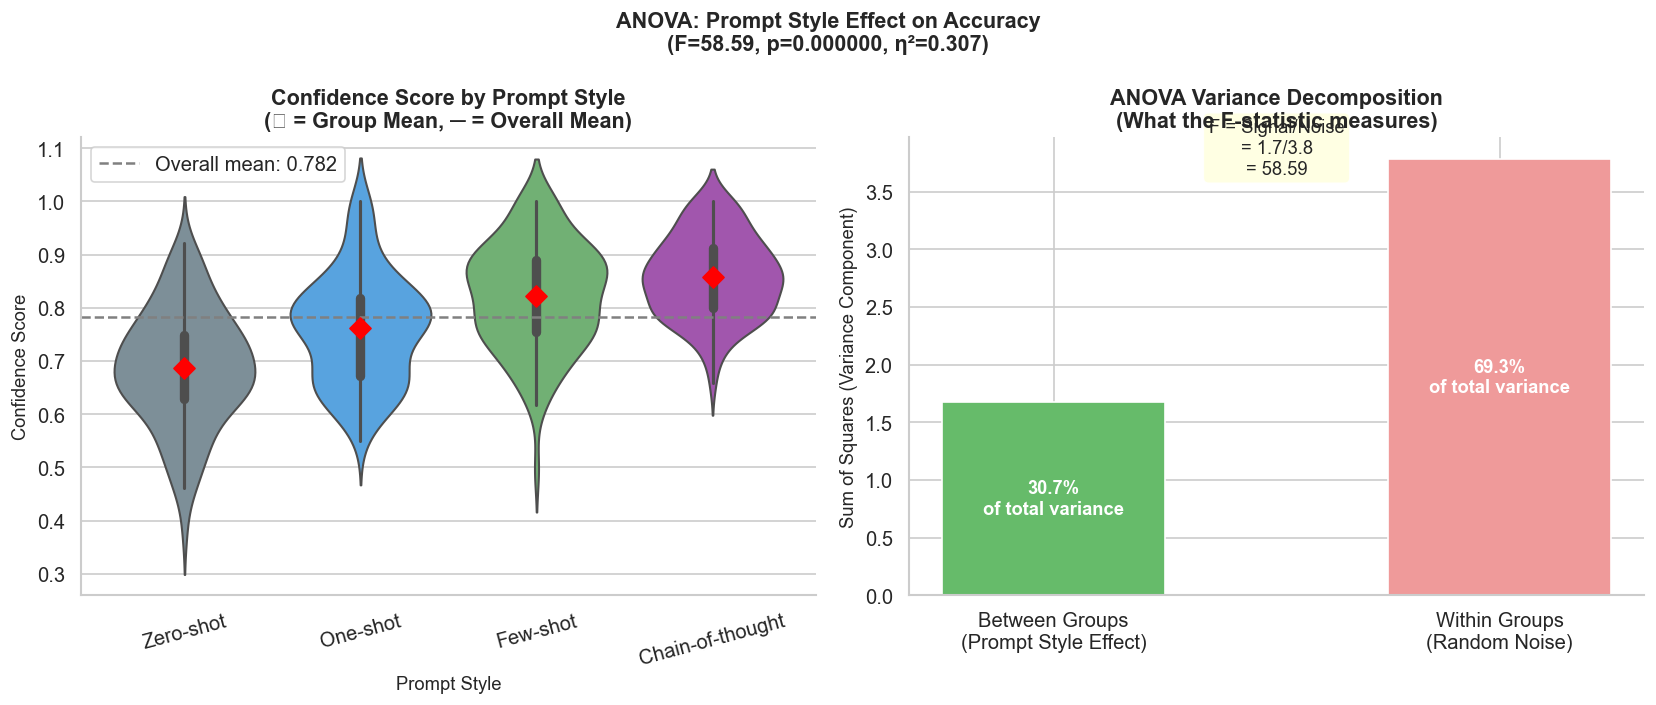

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 6.3 — ANOVA Visualization
# ─────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'ANOVA: Prompt Style Effect on Accuracy\n(F={f_stat:.2f}, p={p_anova:.6f}, η²={eta_squared:.3f})',
             fontsize=13, fontweight='bold')

# ── LEFT: Violin plot across all 4 groups ────────────────────
df_anova = pd.DataFrame([
    {'confidence': score, 'style': style}
    for style, scores in prompt_styles.items()
    for score in scores
])

style_order = list(prompt_styles.keys())
anova_palette = dict(zip(style_order, ['#78909C', '#42A5F5', '#66BB6A', '#AB47BC']))

sns.violinplot(
    data=df_anova, x='style', y='confidence',
    order=style_order, palette=anova_palette,
    inner='box',
    ax=ax1
)

# Add mean markers
for i, (style, scores) in enumerate(prompt_styles.items()):
    ax1.scatter(i, scores.mean(), color='red', s=80, zorder=5, marker='D')

# Add overall mean line
ax1.axhline(overall_mean, color='gray', linewidth=1.5, linestyle='--',
            label=f'Overall mean: {overall_mean:.3f}')

ax1.set_title('Confidence Score by Prompt Style\n(◆ = Group Mean, ─ = Overall Mean)')
ax1.set_xlabel('Prompt Style')
ax1.set_ylabel('Confidence Score')
ax1.tick_params(axis='x', rotation=15)
ax1.legend()

# ── RIGHT: Variance decomposition bar chart ──────────────────
# WHAT: Visualize the ANOVA variance decomposition.
# MOTIVE: Show the signal-to-noise ratio the F-test measures.
# Between-group variance (signal) >> Within-group variance (noise) → high F → significant.

SS_within = SS_total - SS_between   # Within-group variance (residuals)

components = ['Between Groups\n(Prompt Style Effect)', 'Within Groups\n(Random Noise)']
values     = [SS_between, SS_within]
colors_bar = ['#66BB6A', '#EF9A9A']

bars = ax2.bar(components, values, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    pct = val / SS_total * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
             f'{pct:.1f}%\nof total variance',
             ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax2.set_title('ANOVA Variance Decomposition\n(What the F-statistic measures)')
ax2.set_ylabel('Sum of Squares (Variance Component)')
ax2.text(0.5, 0.92,
         f'F = Signal/Noise\n= {SS_between:.1f}/{SS_within:.1f}\n= {f_stat:.2f}',
         transform=ax2.transAxes, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

---
## Section 7 — Correlation vs. Causation

### Topic
**Correlation** measures the strength and direction of the linear relationship between two variables.
**Causation** means one variable directly causes a change in another.

### Why This Is Critical for AI Engineers
ML models detect correlations extremely well — but they cannot establish causation.
If you act on a spurious correlation as if it were causal, you make wrong decisions:
- Confidence score correlates with message length — but making messages longer doesn't make the model more confident.
- Ice cream sales correlate with drowning rates — but banning ice cream won't prevent drowning (both are caused by summer).

### Types of Correlation Coefficients

| Coefficient | When to Use | What It Measures |
|-------------|-------------|------------------|
| **Pearson (r)** | Continuous, linear relationship | Linear correlation |
| **Spearman (ρ)** | Ordinal or non-linear | Rank correlation (monotonic) |

### Analogy 🕵️
> **Nicholas Cage films and pool drownings.**
> These two variables have a near-perfect correlation in US data.
> Obviously, watching Cage films doesn't cause drowning — both are confounded by summer.
> An ML model would "see" this correlation and potentially act on it.
> An AI engineer knows to ask: *"What confounding variable explains this?"*

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 7.1 — Pearson & Spearman Correlation
# ─────────────────────────────────────────────────────────────
#
# WHAT: Compute and compare Pearson and Spearman correlation between
# model confidence scores and message length.
#
# BUSINESS QUESTION:
# Does the model's confidence increase for longer messages?
# (More text = more context = higher confidence?)
# Or is the relationship driven by something else?

# ── Compute Both Correlation Types ───────────────────────────
# WHY BOTH?
# If Pearson r ≈ Spearman ρ → relationship is linear.
# If Spearman ρ >> Pearson r → relationship exists but is non-linear.
# If both ≈ 0 → no monotonic relationship.

# Combine all data
all_conf = np.concatenate([scores_a, scores_b])
all_len  = np.concatenate([
    df_a['message_len'].values,
    df_b['message_len'].values
])
all_prompt = ['A'] * N_A + ['B'] * N_B

pearson_r,  p_pearson  = pearsonr( all_conf, all_len)
spearman_r, p_spearman = spearmanr(all_conf, all_len)

print("══ CORRELATION ANALYSIS ══")
print(f"Question: Does message length predict model confidence?")
print()
print(f"{'Metric':30s} {'Value':>10} {'p-value':>12} {'Significant?':>14}")
print("─" * 68)
print(f"{'Pearson r':30s} {pearson_r:>10.4f} {p_pearson:>12.4f} {'✅ Yes' if p_pearson < 0.05 else '⚪ No':>14}")
print(f"{'Spearman ρ':30s} {spearman_r:>10.4f} {p_spearman:>12.4f} {'✅ Yes' if p_spearman < 0.05 else '⚪ No':>14}")
print()

strength = abs(pearson_r)
if strength < 0.2:      strength_label = "Very weak / Negligible"
elif strength < 0.4:    strength_label = "Weak"
elif strength < 0.6:    strength_label = "Moderate"
elif strength < 0.8:    strength_label = "Strong"
else:                   strength_label = "Very Strong"

print(f"Correlation strength: {strength_label} (|r| = {strength:.4f})")
print()

# ── Correlation ≠ Causation Warning ─────────────────────────
print("══ CRITICAL INTERPRETATION ══")
if abs(pearson_r) < 0.3:
    print("  Weak correlation. Message length does NOT reliably predict model confidence.")
    print("  Even if the correlation is statistically significant (p < 0.05 due to large n),")
    print("  the effect is practically negligible (r ≈ 0).")
    print("  ⚠️  DO NOT conclude: 'Making messages longer improves accuracy.'")
    print("  Correlation ≠ Causation. This may be confounded by intent category:")
    print("  Complaints (long messages) may be intrinsically harder to classify.")
else:
    print("  Meaningful correlation detected. But still: does length CAUSE confidence?")
    print("  Or does a third variable (intent complexity) affect BOTH?")
    print("  To establish causation: run a controlled experiment where you VARY only length.")

══ CORRELATION ANALYSIS ══
Question: Does message length predict model confidence?

Metric                              Value      p-value   Significant?
────────────────────────────────────────────────────────────────────
Pearson r                         -0.0399       0.5383           ⚪ No
Spearman ρ                         0.0118       0.8557           ⚪ No

Correlation strength: Very weak / Negligible (|r| = 0.0399)

══ CRITICAL INTERPRETATION ══
  Weak correlation. Message length does NOT reliably predict model confidence.
  Even if the correlation is statistically significant (p < 0.05 due to large n),
  the effect is practically negligible (r ≈ 0).
  ⚠️  DO NOT conclude: 'Making messages longer improves accuracy.'
  Correlation ≠ Causation. This may be confounded by intent category:
  Complaints (long messages) may be intrinsically harder to classify.


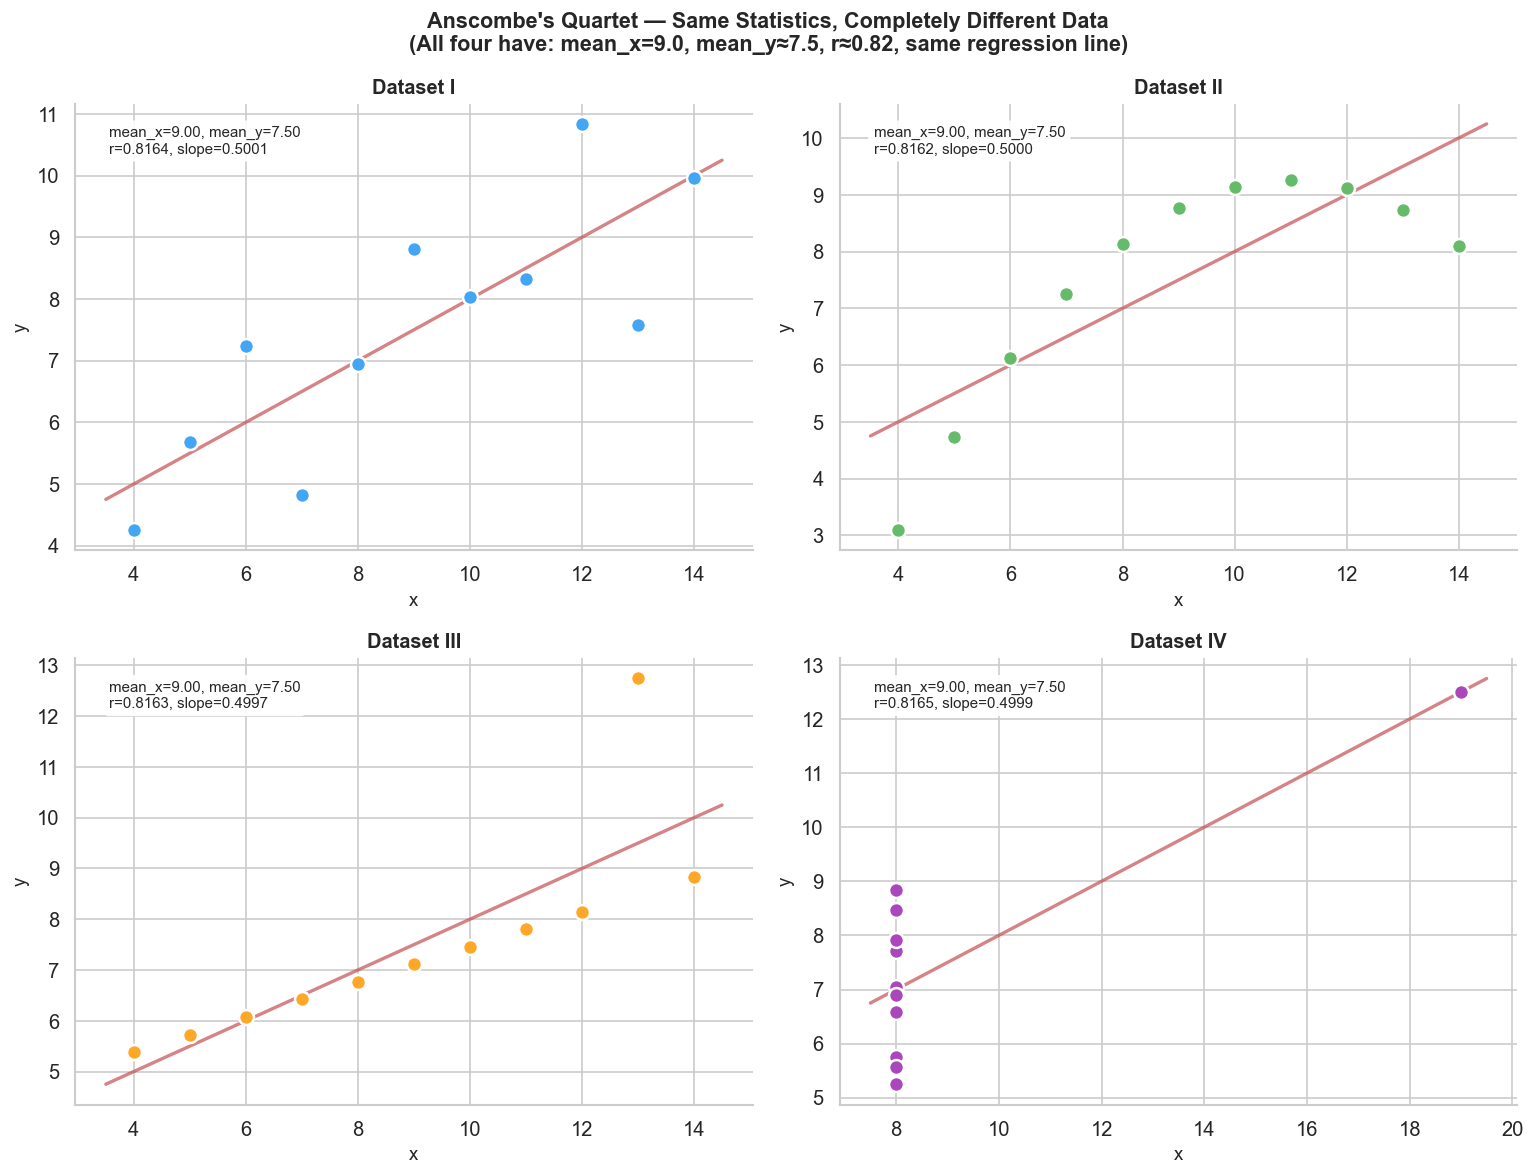


📌 KEY LESSON FROM ANSCOMBE'S QUARTET:
  Dataset I:   Classic linear relationship — correlation is valid.
  Dataset II:  Curved (quadratic) relationship — linear correlation MISLEADS.
  Dataset III: One extreme outlier drives the r=0.82 — without it, r ≈ 0.99.
  Dataset IV:  Almost no real relationship — one leverage point forces r=0.82.

  ➡️  ALWAYS visualize data before reporting correlation coefficients.
  ➡️  Check for non-linearity, outliers, and leverage points first.


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 7.2 — Anscombe's Quartet: Same Statistics, Different Data
# ─────────────────────────────────────────────────────────────
#
# WHAT: Four datasets with IDENTICAL summary statistics but completely
# different visual structures.
#
# MOTIVE: The single most important visualization lesson in statistics.
# Never trust statistics alone — ALWAYS plot your data.
# A correlation of r=0.82 means nothing without seeing the scatterplot.
#
# ANALOGY: Four patients with identical blood test results — but one has
# a broken arm, one has an infection, one is healthy, one has a rare condition.
# The numbers alone hide the real story.

# Anscombe's Quartet (classical dataset, manually defined)
anscombe = {
    'I':   {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]},
    'II':  {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]},
    'III': {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]},
    'IV':  {'x': [8,8,8,8,8,8,8,19,8,8,8],
             'y': [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]},
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Anscombe's Quartet — Same Statistics, Completely Different Data\n"
             "(All four have: mean_x=9.0, mean_y≈7.5, r≈0.82, same regression line)",
             fontsize=13, fontweight='bold')

colors = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']

for ax, (name, data), color in zip(axes.flat, anscombe.items(), colors):
    x, y = np.array(data['x']), np.array(data['y'])

    ax.scatter(x, y, color=color, s=80, zorder=5, edgecolors='white', linewidth=1.5)

    # Fit and plot regression line (identical across all 4)
    slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min()-0.5, x.max()+0.5, 100)
    ax.plot(x_line, slope*x_line + intercept, 'r-', linewidth=2, alpha=0.7)

    # Annotate statistics
    ax.text(0.05, 0.95,
            f'mean_x={x.mean():.2f}, mean_y={y.mean():.2f}\n'
            f'r={r_val:.4f}, slope={slope:.4f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ax.set_title(f'Dataset {name}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

print("\n📌 KEY LESSON FROM ANSCOMBE'S QUARTET:")
print("  Dataset I:   Classic linear relationship — correlation is valid.")
print("  Dataset II:  Curved (quadratic) relationship — linear correlation MISLEADS.")
print("  Dataset III: One extreme outlier drives the r=0.82 — without it, r ≈ 0.99.")
print("  Dataset IV:  Almost no real relationship — one leverage point forces r=0.82.")
print()
print("  ➡️  ALWAYS visualize data before reporting correlation coefficients.")
print("  ➡️  Check for non-linearity, outliers, and leverage points first.")

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 7.3 — Confounders: The Hidden Third Variable
# ─────────────────────────────────────────────────────────────
#
# WHAT: Demonstrate how a confounder creates spurious correlation.
# MOTIVE: This is the #1 mistake in applied ML and data analysis.
#
# SCENARIO: We observe that bKash orders have higher model confidence.
# Does bKash CAUSE the model to be more confident?
# Or is it because bKash users make MORE Electronics purchases
# (which have clearer intent and are easier to classify)?
# Payment method is a CONFOUNDER hiding the real driver: product category.

np.random.seed(SEED)

# Simulate simplified data with hidden confounding
n_sim = 600
payment_methods = np.random.choice(['bKash', 'Nagad', 'COD'], size=n_sim, p=[0.4, 0.3, 0.3])

# Hidden confounder: Electronics buyers prefer bKash AND have clearer intent
# (Electronics purchases: "I want an iPhone 15" is clearer than "my order was bad")
is_electronics = np.where(
    payment_methods == 'bKash',
    np.random.binomial(1, 0.60, n_sim),  # 60% of bKash orders are Electronics
    np.random.binomial(1, 0.20, n_sim)   # Only 20% of other payment methods are Electronics
).astype(bool)

# Confidence is driven by category, NOT payment method
confidence_sim = np.where(
    is_electronics,
    np.random.normal(0.85, 0.08, n_sim),  # Electronics: high clarity → high confidence
    np.random.normal(0.68, 0.12, n_sim)   # Others: more ambiguous
).clip(0, 1)

df_conf = pd.DataFrame({
    'payment':     payment_methods,
    'is_electronics': is_electronics,
    'confidence':  confidence_sim
})

print("══ CONFOUNDER ANALYSIS ══")
print()
print("OBSERVED (NAIVE):")
print("  Average confidence by payment method (appears causal):")
naive = df_conf.groupby('payment')['confidence'].agg(['mean', 'count'])
print(naive.round(4).to_string())

print()
print("AFTER CONTROLLING FOR CATEGORY (TRUE picture):")
print("  Average confidence by category (the real driver):")
print(df_conf.groupby('is_electronics')['confidence'].agg(['mean', 'count']).round(4).rename(
    index={True: 'Electronics', False: 'Non-Electronics'}).to_string())

print()
print("  Within Electronics only — difference by payment:")
print(df_conf[df_conf['is_electronics']].groupby('payment')['confidence'].mean().round(4).to_string())

print()
print("  Within Non-Electronics only — difference by payment:")
print(df_conf[~df_conf['is_electronics']].groupby('payment')['confidence'].mean().round(4).to_string())

print()
print("CONCLUSION: When you control for category, the payment method difference disappears.")
print("The 'bKash → higher confidence' was SPURIOUS. Category was the real driver.")
print("➡️  Payment method does NOT cause confidence. Optimizing prompts for bKash would be WRONG.")

══ CONFOUNDER ANALYSIS ══

OBSERVED (NAIVE):
  Average confidence by payment method (appears causal):
           mean  count
payment               
COD      0.7065    186
Nagad    0.7227    170
bKash    0.7848    244

AFTER CONTROLLING FOR CATEGORY (TRUE picture):
  Average confidence by category (the real driver):
                   mean  count
is_electronics                
Non-Electronics  0.6803    383
Electronics      0.8534    217

  Within Electronics only — difference by payment:
payment
COD      0.8514
Nagad    0.8547
bKash    0.8536

  Within Non-Electronics only — difference by payment:
payment
COD      0.6693
Nagad    0.6944
bKash    0.6767

CONCLUSION: When you control for category, the payment method difference disappears.
The 'bKash → higher confidence' was SPURIOUS. Category was the real driver.
➡️  Payment method does NOT cause confidence. Optimizing prompts for bKash would be WRONG.


---
## Section 8 — Full A/B Test Pipeline (Class Achievement)

### What Is This?
This is the **end-to-end statistical pipeline** you run every time you test a prompt change, model update, or feature experiment.
It wraps all concepts from Sections 2–7 into a single, production-ready workflow.

### The A/B Test Decision Framework
```
1. State Hypothesis  →  2. Check Assumptions  →  3. Run Test
                                                       │
                         ┌─────────────────────────────┤
                         ↓                             ↓
                    p < α? YES               p < α? NO
                    Is effect size            Check Power.
                    meaningful?               Need more data?
                         ↓
                   Make Business Decision
```

### Analogy 🚀
> **Mission control for a rocket launch decision.**
> Every system is checked systematically (assumptions).
> A formal "go/no-go" vote is taken (hypothesis test).
> The decision is documented with exact numbers.
> Nobody says "it feels about right" — everything is measured and justified.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 8.1 — Full A/B Test Pipeline Function
# ─────────────────────────────────────────────────────────────
#
# WHAT: A reusable, production-grade A/B test function.
# MOTIVE: In real teams, you run this on every experiment.
# Encapsulating it in a function means:
#   - No copy-paste errors between experiments
#   - Every test follows the same rigorous process
#   - Results are always documented in the same format

def run_ab_test(
    control_scores: np.ndarray,
    treatment_scores: np.ndarray,
    control_name: str = 'Control (Prompt A)',
    treatment_name: str = 'Treatment (Prompt B)',
    alpha: float = 0.05,
    test_type: str = 'two-tailed',
    metric_name: str = 'Mean Confidence Score'
) -> dict:
    """
    Run a complete two-sample A/B hypothesis test.

    Steps:
      1. Summarize both groups
      2. Check normality assumption (Shapiro-Wilk)
      3. Check variance equality (Levene's test)
      4. Choose appropriate test (t-test vs Mann-Whitney U)
      5. Compute effect size (Cohen's d)
      6. Compute confidence interval of the difference
      7. Make a decision and generate a written conclusion

    Parameters
    ----------
    control_scores   : Observed scores for the control group
    treatment_scores : Observed scores for the treatment group
    alpha            : Significance level (default 0.05)
    test_type        : 'two-tailed' or 'one-tailed' (treatment > control)

    Returns
    -------
    dict with all test results and the written conclusion
    """
    sep = "═" * 65
    print(sep)
    print(f"  A/B TEST REPORT: {metric_name}")
    print(sep)

    # ── STEP 1: Group Summaries ──────────────────────────────
    print("\n📊 STEP 1: GROUP SUMMARIES")
    print(f"  {'Metric':25s} {control_name:>22} {treatment_name:>22}")
    print("  " + "─" * 70)

    stats_summary = {
        'n':       (len(control_scores),            len(treatment_scores)),
        'mean':    (control_scores.mean(),          treatment_scores.mean()),
        'median':  (np.median(control_scores),      np.median(treatment_scores)),
        'std':     (control_scores.std(ddof=1),     treatment_scores.std(ddof=1)),
        'min':     (control_scores.min(),           treatment_scores.min()),
        'max':     (control_scores.max(),           treatment_scores.max()),
    }
    for metric, (c_val, t_val) in stats_summary.items():
        fmt = ',' if metric == 'n' else '.4f'
        print(f"  {metric:25s} {c_val:>{22}{fmt}} {t_val:>{22}{fmt}}")

    abs_diff = treatment_scores.mean() - control_scores.mean()
    rel_diff = abs_diff / control_scores.mean() * 100
    print(f"  {'Absolute difference':25s} {abs_diff:>+22.4f}")
    print(f"  {'Relative difference':25s} {rel_diff:>+21.2f}%")

    # ── STEP 2: Normality Check ──────────────────────────────
    # WHY check normality?
    # t-test assumes samples are from approximately normal distributions.
    # With n=120, CLT mostly guarantees this — but we verify formally.
    # If normality fails badly, switch to Mann-Whitney U (non-parametric).
    print("\n🔬 STEP 2: NORMALITY CHECK (Shapiro-Wilk)")
    _, p_norm_c = stats.shapiro(np.random.choice(control_scores,
                                min(50, len(control_scores)), replace=False))
    _, p_norm_t = stats.shapiro(np.random.choice(treatment_scores,
                                min(50, len(treatment_scores)), replace=False))

    # WHY min(50): Shapiro-Wilk is designed for small samples (<50).
    # For large n, even tiny deviations from normal give p<0.05.
    # We subsample 50 to get a meaningful normality assessment.
    print(f"  {control_name}: p={p_norm_c:.4f}  {'✅ Normal' if p_norm_c>0.05 else '⚠ Non-normal (but CLT covers us)'}")
    print(f"  {treatment_name}: p={p_norm_t:.4f}  {'✅ Normal' if p_norm_t>0.05 else '⚠ Non-normal (but CLT covers us)'}")
    normality_ok = (p_norm_c > 0.05 and p_norm_t > 0.05) or \
                   (len(control_scores) >= 30 and len(treatment_scores) >= 30)
    print(f"  CLT safety net: n={len(control_scores)}≥30 → {'✅ T-test is valid' if normality_ok else '⚠ Consider Mann-Whitney U'}")

    # ── STEP 3: Variance Equality Check (Levene's Test) ───────
    # WHY Levene's test?
    # t-test with equal_var=False (Welch's) doesn't assume equal variance.
    # But we still report this: if variances are very unequal, it signals
    # the groups may be fundamentally different in nature (not just mean).
    print("\n🔬 STEP 3: EQUAL VARIANCE CHECK (Levene's Test)")
    lev_stat, p_levene = stats.levene(control_scores, treatment_scores)
    equal_var = p_levene > 0.05
    print(f"  Levene statistic: {lev_stat:.4f}, p={p_levene:.4f}")
    print(f"  {'✅ Variances are equal → Standard t-test' if equal_var else '⚠ Variances differ → Using Welch t-test (equal_var=False)'}")

    # ── STEP 4: Run the Test ──────────────────────────────────
    print("\n🧪 STEP 4: HYPOTHESIS TEST")
    print(f"  H₀: μ_treatment = μ_control (no effect)")
    print(f"  H₁: μ_treatment {'≠' if test_type=='two-tailed' else '>'} μ_control ({'two-tailed' if test_type=='two-tailed' else 'one-tailed'})")

    t_stat_ab, p_2tail = ttest_ind(treatment_scores, control_scores, equal_var=False)

    if test_type == 'one-tailed':
        p_final = p_2tail / 2 if t_stat_ab > 0 else 1 - p_2tail / 2
    else:
        p_final = p_2tail

    print(f"  t-statistic: {t_stat_ab:.4f}")
    print(f"  p-value ({test_type}): {p_final:.4f}")

    # ── STEP 5: Effect Size ───────────────────────────────────
    print("\n📐 STEP 5: EFFECT SIZE (Cohen's d)")
    pooled_s = np.sqrt((control_scores.std(ddof=1)**2 + treatment_scores.std(ddof=1)**2) / 2)
    d = abs_diff / pooled_s
    d_label = 'Negligible' if abs(d)<0.2 else ('Small' if abs(d)<0.5 else ('Medium' if abs(d)<0.8 else 'Large'))
    print(f"  Cohen's d = {d:.4f} → {d_label} effect")
    print(f"  Interpretation: Treatment mean is {abs(d):.2f} standard deviations {'above' if d>0 else 'below'} control.")

    # ── STEP 6: Confidence Interval of the Difference ─────────
    print("\n📏 STEP 6: CONFIDENCE INTERVAL OF THE DIFFERENCE")
    se_diff = np.sqrt(
        control_scores.var(ddof=1)/len(control_scores) +
        treatment_scores.var(ddof=1)/len(treatment_scores)
    )
    df_welch = se_diff**4 / (
        (control_scores.var(ddof=1)/len(control_scores))**2 / (len(control_scores)-1) +
        (treatment_scores.var(ddof=1)/len(treatment_scores))**2 / (len(treatment_scores)-1)
    )  # Welch-Satterthwaite degrees of freedom
    t_critical = stats.t.ppf(1 - alpha/2, df=df_welch)
    ci_diff = (abs_diff - t_critical * se_diff, abs_diff + t_critical * se_diff)
    print(f"  95% CI of (treatment − control): [{ci_diff[0]:+.4f}, {ci_diff[1]:+.4f}]")
    if ci_diff[0] > 0:
        print(f"  Both CI bounds are POSITIVE → Treatment is better with 95% confidence.")
    elif ci_diff[1] < 0:
        print(f"  Both CI bounds are NEGATIVE → Treatment is worse with 95% confidence.")
    else:
        print(f"  CI includes 0 → Cannot rule out no difference.")

    # ── STEP 7: Decision ──────────────────────────────────────
    print("\n✅ STEP 7: DECISION")
    reject_h0 = p_final < alpha
    meaningful = abs(d) >= 0.2  # At least small effect

    if reject_h0 and meaningful:
        decision = "SHIP IT — Deploy Prompt B to production."
        reasoning = (f"The improvement is statistically significant (p={p_final:.4f}<α={alpha}) "
                     f"AND practically meaningful (d={d:.3f}, {d_label} effect, "
                     f"+{abs_diff:.4f} or {rel_diff:+.1f}% relative improvement).")
    elif reject_h0 and not meaningful:
        decision = "CAUTION — Significant but practically small. Business judgment required."
        reasoning = (f"Statistically significant (p={p_final:.4f}) but effect size is negligible "
                     f"(d={d:.3f}). With n={len(control_scores)+len(treatment_scores)}, "
                     f"even tiny real effects become significant. Cost of deployment vs. {abs_diff:.4f} gain?")
    else:
        decision = "DO NOT SHIP — Insufficient evidence. Prompt B not proven better."
        reasoning = (f"Failed to reject H₀ (p={p_final:.4f}≥α={alpha}). "
                     f"Observed {rel_diff:+.1f}% difference could be random. "
                     f"Consider increasing sample size or revising the prompt.")

    print(f"  🎯 VERDICT: {decision}")
    print(f"  📋 REASONING: {reasoning}")
    print()
    print(sep)

    return {
        't_stat': t_stat_ab, 'p_value': p_final,
        'cohen_d': d, 'ci_diff': ci_diff,
        'reject_h0': reject_h0, 'decision': decision
    }

print("✅ A/B test pipeline function defined.")
print("Running in next cell...")

✅ A/B test pipeline function defined.
Running in next cell...


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 8.2 — Run the Full A/B Test: Prompt A vs. Prompt B
# ─────────────────────────────────────────────────────────────

results = run_ab_test(
    control_scores   = scores_a,
    treatment_scores = scores_b,
    control_name     = 'Prompt A (Control)',
    treatment_name   = 'Prompt B (Treatment)',
    alpha            = 0.05,
    test_type        = 'one-tailed',
    metric_name      = 'LLM Confidence Score — Intent Classification'
)

═════════════════════════════════════════════════════════════════
  A/B TEST REPORT: LLM Confidence Score — Intent Classification
═════════════════════════════════════════════════════════════════

📊 STEP 1: GROUP SUMMARIES
  Metric                        Prompt A (Control)   Prompt B (Treatment)
  ──────────────────────────────────────────────────────────────────────
  n                                            120                    120
  mean                                      0.7164                 0.7912
  median                                    0.7563                 0.8382
  std                                       0.1818                 0.1864
  min                                       0.2744                 0.1781
  max                                       1.0000                 1.0000
  Absolute difference                      +0.0748
  Relative difference                      +10.44%

🔬 STEP 2: NORMALITY CHECK (Shapiro-Wilk)
  Prompt A (Control): p=0.0086  ⚠ Non-norm

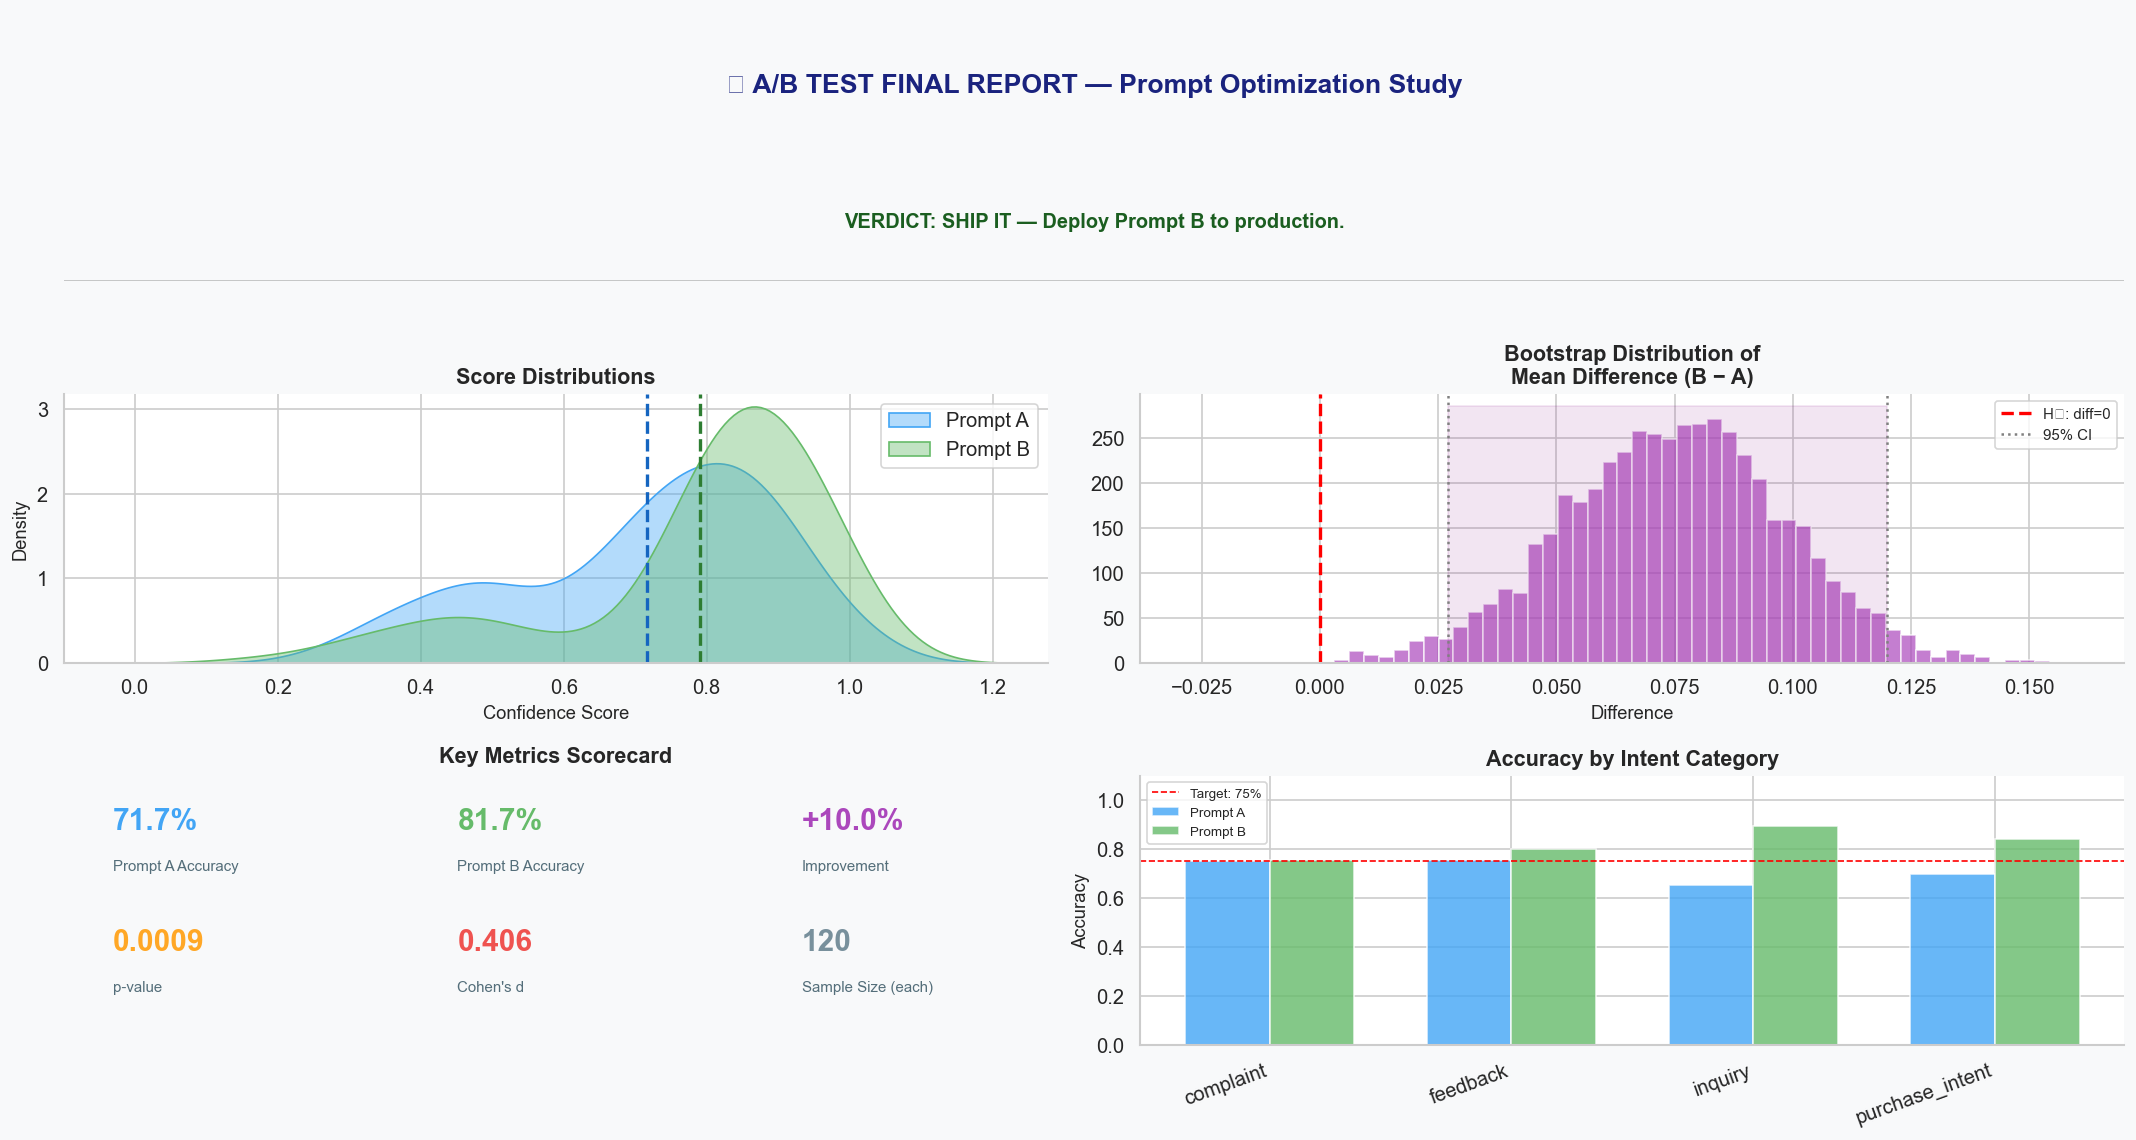


✅ Dashboard saved as 'ab_test_report.png'


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 8.3 — Final A/B Test Dashboard
# ─────────────────────────────────────────────────────────────
#
# WHAT: One professional figure summarizing the entire A/B test.
# MOTIVE: This is what you present to stakeholders.
# Every number they need is in one visual.

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#F8F9FA')

# ── HEADER ──────────────────────────────────────────────────
ax_header = plt.subplot2grid((3, 4), (0, 0), colspan=4)
ax_header.axis('off')
ax_header.text(0.5, 0.7, '📊 A/B TEST FINAL REPORT — Prompt Optimization Study',
               ha='center', fontsize=16, fontweight='bold', color='#1A237E',
               transform=ax_header.transAxes)
verdict_color = '#1B5E20' if results['reject_h0'] else '#B71C1C'
ax_header.text(0.5, 0.2, f"VERDICT: {results['decision']}",
               ha='center', fontsize=12, fontweight='bold', color=verdict_color,
               transform=ax_header.transAxes)
ax_header.axhline(0.0, color='#BDBDBD', linewidth=1)

# ── PANEL 1: Distribution Comparison ────────────────────────
ax1 = plt.subplot2grid((3, 4), (1, 0), colspan=2)
sns.kdeplot(scores_a, ax=ax1, label='Prompt A', fill=True, alpha=0.4, color='#42A5F5')
sns.kdeplot(scores_b, ax=ax1, label='Prompt B', fill=True, alpha=0.4, color='#66BB6A')
ax1.axvline(scores_a.mean(), color='#1565C0', linewidth=2, linestyle='--')
ax1.axvline(scores_b.mean(), color='#2E7D32', linewidth=2, linestyle='--')
ax1.set_title('Score Distributions')
ax1.set_xlabel('Confidence Score')
ax1.legend()

# ── PANEL 2: Bootstrap Distribution of Difference ───────────
ax2 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
np.random.seed(SEED)
boot = [np.random.choice(scores_b, N_B, replace=True).mean() -
        np.random.choice(scores_a, N_A, replace=True).mean()
        for _ in range(5000)]
boot = np.array(boot)
ci_boot = np.percentile(boot, [2.5, 97.5])

ax2.hist(boot, bins=60, color='#AB47BC', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='red', linewidth=2, linestyle='--', label='H₀: diff=0')
ax2.axvline(ci_boot[0], color='gray', linewidth=1.5, linestyle=':', label=f'95% CI')
ax2.axvline(ci_boot[1], color='gray', linewidth=1.5, linestyle=':')
ax2.fill_betweenx([0, ax2.get_ylim()[1] if ax2.get_ylim()[1]>0 else 1],
                  ci_boot[0], ci_boot[1], alpha=0.1, color='purple')
ax2.set_title('Bootstrap Distribution of\nMean Difference (B − A)')
ax2.set_xlabel('Difference')
ax2.legend(fontsize=9)

# ── PANEL 3: KPI Scorecard ───────────────────────────────────
ax3 = plt.subplot2grid((3, 4), (2, 0), colspan=2)
ax3.axis('off')

kpis = [
    ('Prompt A Accuracy',   f"{results_a.mean():.1%}",     '#42A5F5'),
    ('Prompt B Accuracy',   f"{results_b.mean():.1%}",     '#66BB6A'),
    ('Improvement',         f"{results_b.mean()-results_a.mean():+.1%}", '#AB47BC'),
    ('p-value',             f"{results['p_value']:.4f}",   '#FFA726'),
    ("Cohen's d",           f"{results['cohen_d']:.3f}",   '#EF5350'),
    ('Sample Size (each)',  f"{N_A:,}",                    '#78909C'),
]

for i, (label, value, color) in enumerate(kpis):
    col = i % 3
    row = i // 3
    x = col * 0.35 + 0.05
    y = 0.80 - row * 0.45
    ax3.text(x, y,       value, fontsize=18, fontweight='bold', color=color,
             transform=ax3.transAxes)
    ax3.text(x, y-0.15,  label, fontsize=9, color='#546E7A',
             transform=ax3.transAxes)

ax3.set_title('Key Metrics Scorecard', fontweight='bold', pad=8)

# ── PANEL 4: Accuracy by Intent Category ────────────────────
ax4 = plt.subplot2grid((3, 4), (2, 2), colspan=2)

acc_by_intent = df.groupby(['intent', 'prompt'])['correct'].mean().unstack().reset_index()
x_pos = np.arange(len(acc_by_intent))
width = 0.35

if 'Prompt A' in acc_by_intent.columns and 'Prompt B' in acc_by_intent.columns:
    ax4.bar(x_pos - width/2, acc_by_intent['Prompt A'], width,
            label='Prompt A', color='#42A5F5', alpha=0.8)
    ax4.bar(x_pos + width/2, acc_by_intent['Prompt B'], width,
            label='Prompt B', color='#66BB6A', alpha=0.8)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(acc_by_intent['intent'], rotation=20, ha='right')
    ax4.set_ylim(0, 1.1)
    ax4.set_ylabel('Accuracy')
    ax4.axhline(0.75, color='red', linestyle='--', linewidth=1, label='Target: 75%')
    ax4.legend(fontsize=8)

ax4.set_title('Accuracy by Intent Category')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('ab_test_report.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("\n✅ Dashboard saved as 'ab_test_report.png'")

══ STATISTICAL POWER ANALYSIS ══
Effect size (Cohen's d): 0.4060
Significance level α:    0.05
Conventional power target: 0.80 (80%)

Sample Size (n each)        Power               Status
───────────────────────────────────────────────────────
                    10     0.2306       ⚠ Underpowered
                    20     0.3591       ⚠ Underpowered
                    30     0.4712       ⚠ Underpowered
                    50     0.6500       ⚠ Underpowered
                    80     0.8220           ✅ Adequate
                   100     0.8900           ✅ Adequate
                   120     0.9332           ✅ Adequate ← Our experiment
                   150     0.9694           ✅ Adequate
                   200     0.9921           ✅ Adequate
                   300     0.9996           ✅ Adequate
                   500     1.0000           ✅ Adequate

Minimum n per group for 80% power: 76
Our actual n per group: 120
We are adequately powered to detect this effect.


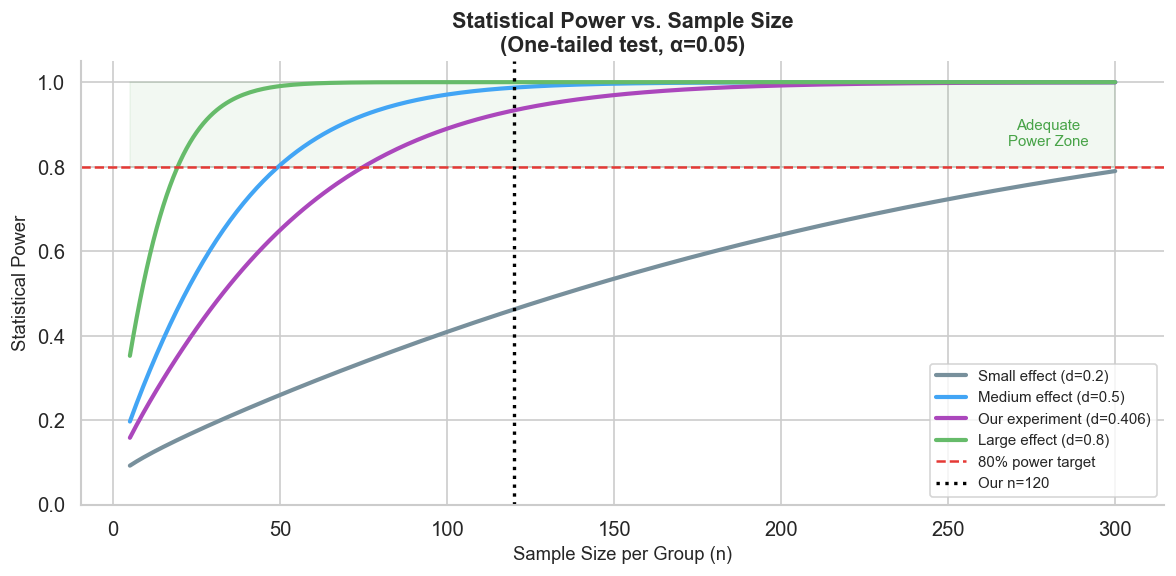


📌 KEY TAKEAWAY:
  Small effects need MUCH larger samples to detect reliably.
  Always run a power analysis BEFORE your experiment to decide on sample size.
  If p > 0.05 AND power < 0.80 → you can't conclude 'no effect' — you're underpowered.


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 8.4 — Statistical Power Analysis
# ─────────────────────────────────────────────────────────────
#
# WHAT: How many samples did we NEED to reliably detect the true effect?
# MOTIVE: If you didn't find significance (p > 0.05), the FIRST question is:
# "Did we have enough data?" Power analysis answers this.
#
# STATISTICAL POWER = P(Reject H₀ | H₁ is TRUE)
#   = Probability of detecting a real effect when it exists
# Conventional target: Power ≥ 0.80 (80%)
#
# Power depends on:
#   - Sample size n (bigger n → more power)
#   - Effect size d (bigger effect → easier to detect)
#   - α (stricter α → less power)
#
# ANALOGY: Power is the sensitivity of your measuring instrument.
# A scale that only shows kg can't detect a 50-gram difference.
# You need a scale with enough precision (power) to detect the effect size you care about.

from scipy.stats import norm

def compute_power(n: int, d: float, alpha: float = 0.05) -> float:
    """
    Compute the statistical power for a two-sample t-test.

    Formula: Power = P(Z > z_α - d√(n/2)) for one-tailed test
    where z_α is the critical z-value at significance level α.

    WHY √(n/2): For two groups of equal size n,
    the non-centrality parameter is d × √(n/2).
    """
    z_alpha  = norm.ppf(1 - alpha)        # Critical value (1.645 for α=0.05 one-tailed)
    ncp      = d * np.sqrt(n / 2)         # Non-centrality parameter
    power    = 1 - norm.cdf(z_alpha - ncp)
    return power


true_d = results['cohen_d']   # Effect size from our experiment

print("══ STATISTICAL POWER ANALYSIS ══")
print(f"Effect size (Cohen's d): {true_d:.4f}")
print(f"Significance level α:    {ALPHA}")
print(f"Conventional power target: 0.80 (80%)")
print()
print(f"{'Sample Size (n each)':22s} {'Power':>10} {'Status':>20}")
print("─" * 55)

for n in [10, 20, 30, 50, 80, 100, 120, 150, 200, 300, 500]:
    power = compute_power(n, true_d, ALPHA)
    status = "✅ Adequate" if power >= 0.80 else "⚠ Underpowered"
    highlight = " ← Our experiment" if n == 120 else ""
    print(f"{n:>22,} {power:>10.4f} {status:>20}{highlight}")

# ── Minimum sample size for 80% power ────────────────────────
# Find the minimum n where power >= 0.80
n_required = next(n for n in range(1, 1000) if compute_power(n, true_d, ALPHA) >= 0.80)
print()
print(f"Minimum n per group for 80% power: {n_required}")
print(f"Our actual n per group: {N_A}")
print(f"We {'are' if N_A >= n_required else 'are NOT'} adequately powered to detect this effect.")

# ── Power curve ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

n_range = np.arange(5, 301)
for d_val, color, label in [
    (0.2, '#78909C', 'Small effect (d=0.2)'),
    (0.5, '#42A5F5', 'Medium effect (d=0.5)'),
    (true_d, '#AB47BC', f'Our experiment (d={true_d:.3f})'),
    (0.8, '#66BB6A', 'Large effect (d=0.8)'),
]:
    powers = [compute_power(n, d_val) for n in n_range]
    ax.plot(n_range, powers, color=color, linewidth=2.5, label=label)

ax.axhline(0.80, color='#E53935', linewidth=1.5, linestyle='--', label='80% power target')
ax.axvline(N_A,  color='black',   linewidth=2,   linestyle=':', label=f'Our n={N_A}')

ax.set_title('Statistical Power vs. Sample Size\n(One-tailed test, α=0.05)', fontsize=13)
ax.set_xlabel('Sample Size per Group (n)')
ax.set_ylabel('Statistical Power')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.fill_between(n_range, 0.80, 1.0, alpha=0.05, color='green')
ax.text(280, 0.85, 'Adequate\nPower Zone', ha='center', fontsize=9, color='green', alpha=0.7)

plt.tight_layout()
plt.show()

print()
print("📌 KEY TAKEAWAY:")
print("  Small effects need MUCH larger samples to detect reliably.")
print("  Always run a power analysis BEFORE your experiment to decide on sample size.")
print("  If p > 0.05 AND power < 0.80 → you can't conclude 'no effect' — you're underpowered.")

---
## Summary: Complete Hypothesis Testing Reference Card

| Test | Use When | scipy Function | Key Output |
|------|----------|----------------|------------|
| **One-sample t-test** | Compare sample mean to a known target | `ttest_1samp(data, popmean)` | t-stat, p-value |
| **Two-sample t-test (Welch)** | Compare means of 2 independent groups | `ttest_ind(a, b, equal_var=False)` | t-stat, p-value |
| **Paired t-test** | Same subjects measured twice (before/after) | `ttest_rel(before, after)` | t-stat, p-value |
| **One-way ANOVA** | Compare means of 3+ independent groups | `f_oneway(g1, g2, g3, ...)` | F-stat, p-value |
| **Mann-Whitney U** | Two groups, non-normal, non-parametric | `mannwhitneyu(a, b)` | U-stat, p-value |
| **Shapiro-Wilk** | Test if a sample is normally distributed | `shapiro(data)` | W-stat, p-value |
| **Levene's Test** | Test if two groups have equal variance | `levene(a, b)` | W-stat, p-value |
| **Pearson r** | Linear correlation, continuous data | `pearsonr(x, y)` | r, p-value |
| **Spearman ρ** | Rank correlation, ordinal/non-linear | `spearmanr(x, y)` | ρ, p-value |

---

## Decision Tree: Which Test to Use?

```
How many groups?
    │
    ├── 1 group vs. a target value → One-sample t-test
    │
    ├── 2 groups ──→ Are they independent?
    │                    │
    │                    ├── YES → Is data normal (n≥30 or Shapiro p>0.05)?
    │                    │             │
    │                    │             ├── YES → Two-sample t-test (Welch)
    │                    │             └── NO  → Mann-Whitney U
    │                    │
    │                    └── NO (same subjects, before/after) → Paired t-test
    │
    └── 3+ groups → ANOVA → Post-hoc Bonferroni/Tukey if significant
```

---

## Exercises

### Exercise 1 — Repeat the A/B Test with Different Sample Sizes
Change `N_A = N_B = 30` (instead of 120) in Cell 1.2 and re-run everything.
Does the test still detect the difference? What happens to the p-value and power?

### Exercise 2 — Run a Paired T-Test
Imagine the SAME 120 messages were evaluated by BOTH prompts (paired design).
Use `scipy.stats.ttest_rel(scores_a, scores_b)`. Compare the p-value to the independent test.
Why is the paired test usually more powerful?

### Exercise 3 — Multiple Testing Correction
Suppose you test 10 different prompt variations simultaneously.
What is the Bonferroni-corrected α? Run all 10 pairwise tests and report which pairs survive correction.

### Exercise 4 — Find a Confounding Variable
In the dataset, does accuracy differ by `intent` category?
If yes: is the Prompt B advantage uniform across all intents, or concentrated in one?
What does that tell you about where to focus prompt engineering effort?

### Exercise 5 — Power Calculation Before an Experiment
Before running an experiment, your team expects a Cohen's d ≈ 0.3 (small-medium effect).
Use `compute_power()` to find the minimum n per group needed for 80% power at α=0.05.
How does the answer change if you require 90% power?

---
*End of Class 7 Notebook — Statistics for AI: Hypothesis Testing*

*Next Class → Linear Algebra for ML: Vectors, Matrices, Dot Products, and Eigenvalues*